<h1> Задание по Uplift-моделированию </h1>

<h2>Введение</h2>

Перед вами типичная задача, возникающая при работе с моделями кампейнинга в банке: заказчик запустил несколько пилотов по взаимодействию с клиентами с помощью разных каналов: push в мобильном приложении, sms, баннеры в мобильном приложении и реклама в других приложениях экосистемы. Заказчик хотел бы понимать, какой канал взаимодействия с клиентом наиболее эффективен для каждого клиента из клиентской базы. Кампании планируются и запускаются в ежемесячном режиме. Иными словами, заказчик хотел бы в идеале ежемесячно получать список клиентов, которым необходимо отправить коммуникацию с указанием канала и прироста вероятности покупки в случае, если клиенту отправят коммуникацию по сравнению с тем случаем, когда клиенту коммуникацию не отправят.

<b>Таким образом: </b>
1.	У нас есть база клиентов (клиенты, имеющие id в банке). По данной базе осуществляется рассылка тех или иных стимулирующих коммуникаций по различным продуктам, каналам (например SMS, Push, баннеры в мобильном приложении и т.д.) и сегментам клиентов
2.	Признаковое описание клиента состоит из различных агрегатов действий клиента за месяц или его объективных характеристик: например, средняя сумма средств на депозитах за месяц, среднее число кликов клиента в день за месяц в разделе "инвестиции" в мобильном приложении или возраст клиента
3.	При формировании обучающей/тестовой выборки допускается, что один и тот же клиент за разные месяцы — это разные объекты. То есть допускается, что клиент в феврале и клиент в марте — это разные клиенты (то есть мы можем оперировать с ними как с разными сущностями).
4.	Агрегаты действий клиента за месяц появляются примерно 10 числа следующего месяца. То есть, например, агрегаты за декабрь появляются 10 января. В свою очередь списки клиентов, которым необходимо осуществить рассылку должны быть сформированы ориентировочно 20 числа предыдущего месяца. Таким образом, <b> модель должна быть обучена делать предсказания с лагом в два месяца </b>, то есть должна делать предсказание на март по клиентским агрегатам за январь. Обязательно учтите это при обучении модели (в противном случае можно получить лик таргета, так как часто величину, которую мы предсказываем уже есть в клиентских агрегатах, но смещенная на два месяца).


## Оценивание задания:

Всего за задание можно получить 50 первичных баллов, которые затем переводятся в 10-балльную шкалу делением не 5.

Скачаем архив с данными по ссылке и разархивируем.

In [ ]:
!pip install gdown -q

In [ ]:
import gdown

url = 'https://drive.google.com/uc?id=19nKGaxm3RwHxh2UWPo537_-MDx21AkHO'
output = 'Data.zip'
gdown.download(url, output, quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=19nKGaxm3RwHxh2UWPo537_-MDx21AkHO
From (redirected): https://drive.google.com/uc?id=19nKGaxm3RwHxh2UWPo537_-MDx21AkHO&confirm=t&uuid=a749c53b-2025-4768-854e-12b3c2c6ee7f
To: /content/Data.zip
100%|██████████| 289M/289M [00:06<00:00, 42.2MB/s]


'Data.zip'

In [ ]:
import zipfile

with zipfile.ZipFile('Data.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/')

In [201]:
!pip uninstall -y causalml scikit-learn numpy scipy
!pip install scikit-learn==1.2.2 numpy==1.23.5 scipy causalml

Found existing installation: causalml 0.15.2
Uninstalling causalml-0.15.2:
  Successfully uninstalled causalml-0.15.2
Found existing installation: scikit-learn 1.2.2
Uninstalling scikit-learn-1.2.2:
  Successfully uninstalled scikit-learn-1.2.2
Found existing installation: numpy 1.23.5
Uninstalling numpy-1.23.5:
  Successfully uninstalled numpy-1.23.5
Found existing installation: scipy 1.15.2
Uninstalling scipy-1.15.2:
  Successfully uninstalled scipy-1.15.2
  Using cached scikit_learn-1.2.2-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (11 kB)
  Using cached numpy-1.23.5-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (2.3 kB)
  Using cached scipy-1.15.2-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
  Using cached causalml-0.15.3-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (10 kB)
INFO: pip is looking at multiple versions of causalml to determine which version is compatible with other requi

In [1]:
!pip install optuna

In [2]:
!pip install catboost

In [3]:
!pip install scikit-uplift

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (train_test_split,
                                     cross_validate,
                                     StratifiedKFold)
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.calibration import CalibratedClassifierCV

from causalml.dataset import make_uplift_classification
from causalml.inference.tree import UpliftRandomForestClassifier

import optuna

from catboost import CatBoostClassifier

from sklift.models import (SoloModel,
                           TwoModels,
                           ClassTransformation,
                           ClassTransformationReg)

from sklift.metrics import (uplift_at_k,
                            uplift_auc_score,
                            qini_auc_score,
                            make_uplift_scorer)

from sklift.viz import plot_qini_curve
from sklift.viz import plot_uplift_curve

ERROR:duecredit:Failed to import duecredit due to No module named 'duecredit'


<h2>Описание данных</h2>

Перед вами несколько наборов данных, на основе которых вам будет необходимо обучить Uplift модели, сделать прогноз на нужный месяц и решить, кому из клиентов отправлять коммуникацию, а кому коммуникацию отправлять не следует.

<h3>Features </h3> Признаки клиентов, клиентские агрегаты, которые описывают поведение клиентов <br>

1. user_id - id клиента
2. report_dt - месяц, на который актуальны признаки
3. city - город, в котором живет клиент
4. age - возраст клиента
5. x1 – x9 - числовые признаки клиента, характеризующие поведение клиента

Первичный ключ таблицы - user_id + report_dt

<h3> Contracts </h3> Таблица с покупками продуктов.

1. contract_id - id покупки
2. user_id - id пользователя, который совершил покупку
3. product_id - id продукта, который был куплен
4. contract_ts – дата момента, когда была совершена покупка

Первичный ключ - contract_id


<h3> Campaings </h3> Кампании, которые проводились (под кампанией мы понимаем рассылку sms, push и т.д).

1. campaing_id - id кампании, первичный ключ таблицы
2. product_id - продукт, по которому проводилась кампания (считаем, что продукты не конкурируют друг с другом)
3. channel - канал, в котором проводилась кампания


<h3> People_in_campaings </h3> Люди, которые принимали участие в кампаниях.

1. campaing_id - id кампании
2. user_id - id пользователя, который попал в кампанию
3. флаг целевой (1) и контрольной (0) группы (целевая группа - это те, кто получил коммуникацию, а контрольная - те, кто нет)
4. delivery_ts - timestamp, когда клиенту фактически была доставлена коммуникация (для контрольной группы nan, подумайте почему)

Первичный ключ данной таблицы - user_id + campaing_id


<h3> Contracts </h3> Таблица с покупками продуктов

1. contract_id - id покупки
2. user_id - id пользователя, который совершил покупку
3. product_id - id продукта, который был куплен
4. contract_ts – дата момента, когда была совершена покупка

Первичный ключ - contract_id


<h1> Постановка задачи </h1> В ноябре 2024 проводилось несколько кампаний по продукту с id 0001 (фактически клиенту рассылалось одно и тоже сообщение, но в разных каналах). Вам необходимо по данным кампаниям построить модель, которая будет определять лучший канал коммуникации каждого клиента и определить, кому из клиентов в марте 2025 отправить какую коммуникацию, а кому коммуникацию вообще отправлять не следует.
Ответ нужно представить в следующем виде (report_dt – дата фичей):

<table>
  <thead>
    <tr>
      <th>user_id</th>
      <th>report_dt</th>
      <th>channel</th>
      <th>uplift</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>10045</td>
      <td>2025-01-31</td>
      <td>banner</td>
      <td>0.07</td>
    </tr>
    <tr>
      <td>10046</td>
      <td>2025-01-31</td>
      <td>no_comm</td>
      <td>0.00</td>
    </tr>
    <tr>
      <td>10047</td>
      <td>2025-01-31</td>
      <td>sms</td>
      <td>0.23</td>
    </tr>
    <tr>
      <td>10048</td>
      <td>2025-01-31</td>
      <td>push</td>
      <td>0.19</td>
    </tr>
  </tbody>
</table>

<h1> Декомпозиция задачи </h1>

<h2> 1.	Сбор и анализ таргета (18 баллов)</h2>

Прежде всего, вам необходимо собрать целевое событие, которое вы собираетесь прогнозировать. В данном случае целевое событие - это покупка продукта 0001 пользователем, участвовавшем в кампании. Обратите внимание, что не все пользователи получают коммуникацию одновременно (delivery_ts в таблице People_in_campaings). Согласно правилу, согласованному с заказчиком, <b> человек из целевой группы купил продукт после коммуникации - это значит, что он купил его в течение 2х недель после получения сообщения, а человек из контрольной - в течение 3х недель с момента старта кампании (старт кампании - начало месяца). </b> То есть для определенной кампании, для каждого клиента, попавшего в кампанию, вам надо будет найти его покупки данного продукта, а потом основываяся на данном правиле превратить покупки в 0 или 1. <br> На выходе у вас должен появиться таблица с целевым действием для каждого канала (колонки client_id, report_dt,  target), где таргет - это бинарная переменная (0 или 1). Колонка report_dt вам нужна как техническая колонка для дальнейших джоинов.<br><br>

Проведите анализ полученных данных (до присоединения клиентских агрегатов). Какие проблемы и сложности в данных вы обнаружили? Что с ними можно сделать? Какая из кампаний наиболее эффективная? Подготовьте выводы по полученным инсайтам.


**Комментарий по заданиям и оцениванию:**

* Вы должны самостоятельно сделать join нескольких таблиц, самостоятельно собрать целевое действие

* Представлены 4 различных канала, за таргет по каждому из каналов можно получить **максимум 2 балла**:
    * 1 балл за то, что просчитано целевое действие для целевой группы (покупка в
течение одной-двух недель с момента получения коммуникации)
    * 1 балл за то, что просчитано целевое действие для контрольной группы (покупка в течение двух-трех недель с момента старта кампании) и сделана таблица в требуемом формате

* Обратите внимание, что не во всех кампаниях содержатся корректные данные для проведения моделирования, и вам необходимо провести анализ данных и в случае выявленных некорректностей - описать их, и не проводить моделирование для "сломанной" кампании  
    * За данный анализ можно получить **8 баллов**

* Вы должны оценить эффективность кампаний по uplift (cреднее значение таргета в целевой минус среднее значение таргета в контрольной группе)
    * За данный анализ можно получить **2 балла**

In [6]:
features = pd.read_csv('/content/ДЗ по Uplift обновленное/AGGS_FINAL.csv', index_col=0)
contracts = pd.read_csv('/content/ДЗ по Uplift обновленное/CONTRACTS_FINAL.csv', index_col=0)
campaings = pd.read_csv('/content/ДЗ по Uplift обновленное/CAMPAINGS.csv', index_col=0)
people = pd.read_csv('/content/ДЗ по Uplift обновленное/PEOPLE_IN_CAMPAINGS_FINAL.csv', index_col=0)

In [7]:
print(features.shape)
print(contracts.shape)
print(campaings.shape)
print(people.shape)

(2760000, 13)
(286316, 4)
(4, 3)
(520000, 4)


In [8]:
features.head(5)

,x1,x2,x3,x4,x5,x6,x7,x8,x9,report_dt,user_id,age,city
104548,0.654343,-1.439286,-0.011475,2.039457,0.843580,-0.977480,-0.768019,-1.044127,0.025673,2025-01-31,1066338,26,Ufa
38396,2.583579,1.755569,3.360186,-1.122864,0.034201,-0.269607,-1.503646,1.040289,-1.691606,2024-11-30,13900,35,Ufa
227077,0.296030,-0.937075,1.073280,1.874636,-0.981216,-1.100187,-0.331181,-1.575637,0.474965,2025-03-31,4063636,28,Ufa
304649,2.329328,-1.345159,0.345066,0.755373,-0.082842,0.028439,0.919211,0.808793,-0.560004,2025-03-31,1025488,27,Moscow
239518,0.167643,1.587099,0.165357,0.289758,-1.108840,-1.501819,0.615588,1.631203,-0.208419,2025-02-28,4040555,37,Moscow


In [9]:
contracts.head(5)

,user_id,contract_date,product_id,contract_id
39735,4008279,2024-11-03,1,0001_2024-11-03_4008279
44062,2079035,2024-11-08,1,0001_2024-11-08_2079035
9286,103088,2024-11-13,1,0001_2024-11-13_103088
45573,2026788,2024-11-02,1,0001_2024-11-02_2026788
150378,52269,2024-11-17,1,0001_2024-11-17_52269


In [10]:
campaings.head(5)

,campaing_id,product_id,channel
0,iddqd,1,push
1,idclip,1,sms
2,iddt,1,banner
3,idkfa,1,other_ads


In [11]:
people.head(5)

,campaing_id,user_id,t_flag,delivery_date
29299,idclip,1099975,1,2024-11-06
36627,iddqd,1162,1,2024-11-08
134015,iddqd,42991,1,2024-11-07
57441,idclip,142343,0,unknown
48671,iddqd,24623,0,unknown


In [12]:
features.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2760000 entries, 104548 to 454256
Data columns (total 13 columns):
 #   Column     Dtype  
---  ------     -----  
 0   x1         float64
 1   x2         float64
 2   x3         float64
 3   x4         float64
 4   x5         float64
 5   x6         float64
 6   x7         float64
 7   x8         float64
 8   x9         float64
 9   report_dt  object 
 10  user_id    int64  
 11  age        int64  
 12  city       object 
dtypes: float64(9), int64(2), object(2)
memory usage: 294.8+ MB


In [13]:
contracts.info()

<class 'pandas.core.frame.DataFrame'>
Index: 286316 entries, 39735 to 30945
Data columns (total 4 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   user_id        286316 non-null  int64 
 1   contract_date  286316 non-null  object
 2   product_id     286316 non-null  int64 
 3   contract_id    286316 non-null  object
dtypes: int64(2), object(2)
memory usage: 10.9+ MB


In [14]:
people.info()

<class 'pandas.core.frame.DataFrame'>
Index: 520000 entries, 29299 to 148522
Data columns (total 4 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   campaing_id    520000 non-null  object
 1   user_id        520000 non-null  int64 
 2   t_flag         520000 non-null  int64 
 3   delivery_date  520000 non-null  object
dtypes: int64(2), object(2)
memory usage: 19.8+ MB


In [15]:
campaings.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4 entries, 0 to 3
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   campaing_id  4 non-null      object
 1   product_id   4 non-null      int64 
 2   channel      4 non-null      object
dtypes: int64(1), object(2)
memory usage: 128.0+ bytes


In [16]:
contracts['user_id'].nunique()

286316

In [17]:
people['user_id'].nunique()

460000

In [18]:
merged = people.merge(campaings, on='campaing_id', how='left')

In [19]:
merged = merged.merge(contracts, on='user_id', how='left')

In [20]:
merged.head(5)

,campaing_id,user_id,t_flag,delivery_date,product_id_x,channel,contract_date,product_id_y,contract_id
0,idclip,1099975,1,2024-11-06,1,sms,2024-11-11,1.0,0001_2024-11-11_1099975
1,iddqd,1162,1,2024-11-08,1,push,2024-11-13,1.0,0001_2024-11-13_1162
2,iddqd,42991,1,2024-11-07,1,push,NaN,NaN,NaN
3,idclip,142343,0,unknown,1,sms,2024-11-17,1.0,0001_2024-11-17_142343
4,iddqd,24623,0,unknown,1,push,NaN,NaN,NaN


In [21]:
merged['contract_id'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 520000 entries, 0 to 519999
Series name: contract_id
Non-Null Count   Dtype 
--------------   ----- 
337635 non-null  object
dtypes: object(1)
memory usage: 4.0+ MB


In [22]:
merged['product_id_x'].value_counts()

,count
product_id_x,
1,520000


In [23]:
merged = merged.drop(columns=['product_id_x', 'product_id_y', 'contract_id'], axis=1)

In [24]:
merged.head(5)

,campaing_id,user_id,t_flag,delivery_date,channel,contract_date
0,idclip,1099975,1,2024-11-06,sms,2024-11-11
1,iddqd,1162,1,2024-11-08,push,2024-11-13
2,iddqd,42991,1,2024-11-07,push,NaN
3,idclip,142343,0,unknown,sms,2024-11-17
4,iddqd,24623,0,unknown,push,NaN


In [25]:
campaign_start = pd.to_datetime('2024-11-01')

In [26]:
def calc_target(row):
    if row['t_flag'] == 1:
        start_date = pd.to_datetime(row['delivery_date'])
        end_date = start_date + pd.Timedelta(weeks=2)
    else:
        start_date = campaign_start
        end_date = start_date + pd.Timedelta(weeks=3)

    contract_date = pd.to_datetime(row['contract_date'])

    if (contract_date >= start_date) and (contract_date <= end_date):
        return 1
    else:
        return 0

In [27]:
merged['target'] = merged.apply(lambda row: calc_target(row), axis=1)

In [28]:
merged.head(5)

,campaing_id,user_id,t_flag,delivery_date,channel,contract_date,target
0,idclip,1099975,1,2024-11-06,sms,2024-11-11,1
1,iddqd,1162,1,2024-11-08,push,2024-11-13,1
2,iddqd,42991,1,2024-11-07,push,NaN,0
3,idclip,142343,0,unknown,sms,2024-11-17,1
4,iddqd,24623,0,unknown,push,NaN,0


In [29]:
merged[merged['t_flag'] == 1]['delivery_date'].value_counts()


,count
delivery_date,
2024-11-07,55943
2024-11-04,55707
2024-11-06,55589
2024-11-05,55241
2024-11-08,37520


In [30]:
merged[merged['t_flag'] == 0]['delivery_date'].value_counts()


,count
delivery_date,
unknown,260000


In [31]:
merged.duplicated().sum()

0

In [32]:
channel_counts = merged['channel'].value_counts(dropna=False)
channel_counts

,count
channel,
push,160000
sms,120000
banner,120000
other_ads,120000


In [33]:
campaign_user_counts = (
    merged.groupby('campaing_id')['user_id']
      .nunique()
      .reset_index(name='unique_users')
      .sort_values('unique_users', ascending=False)
)

print("Число уникальных пользователей в каждой кампании:")
print(campaign_user_counts)

Число уникальных пользователей в каждой кампании:
  campaing_id  unique_users
1       iddqd        160000
0      idclip        120000
2        iddt        120000
3       idkfa        120000


In [34]:
merged.groupby(['campaing_id','channel','t_flag'])['target'].mean()

campaing_id  channel    t_flag
idclip       sms        0         0.684917
                        1         0.201167
iddqd        push       0         0.202150
                        1         0.601738
iddt         banner     0         0.400733
                        1         0.602717
idkfa        other_ads  0         0.400733
                        1         0.602717
Name: target, dtype: float64

In [35]:
merged.groupby(['channel', 't_flag']).size().unstack(fill_value=0)

t_flag,0,1
channel,,
banner,60000,60000
other_ads,60000,60000
push,80000,80000
sms,60000,60000


In [36]:
merged['delivery_date'] = pd.to_datetime(merged['delivery_date'], errors='coerce')
merged['contract_date'] = pd.to_datetime(merged['contract_date'], errors='coerce')

In [37]:
merged.isna().sum()

,0
campaing_id,0
user_id,0
t_flag,0
delivery_date,260000
channel,0
contract_date,182365
target,0


In [38]:
merged['diff_delivery_contract'] = (merged['contract_date'] - merged['delivery_date']).dt.days

In [39]:
merged_flag1 = merged[merged['t_flag'] == 1]

out_of_range_flag1 = merged_flag1[
    (merged_flag1['contract_date'].notna()) &
    ((merged_flag1['diff_delivery_contract'] < 0) | (merged_flag1['diff_delivery_contract'] > 14))
]
print("Записи с некорректным окном (t_flag=1):", len(out_of_range_flag1))
out_of_range_flag1.head()

Записи с некорректным окном (t_flag=1): 89521


,campaing_id,user_id,t_flag,delivery_date,channel,contract_date,target,diff_delivery_contract
6,idkfa,2008409,1,2024-11-04,other_ads,2024-11-02,0,-2.0
7,iddt,4045746,1,2024-11-04,banner,2024-11-01,0,-3.0
8,idclip,1106346,1,2024-11-05,sms,2024-11-25,0,20.0
18,iddt,4026719,1,2024-11-05,banner,2024-11-28,0,23.0
20,idclip,1157443,1,2024-11-07,sms,2024-11-02,0,-5.0


In [40]:
merged['diff_start_contract'] = (merged['contract_date'] - campaign_start).dt.days

In [41]:
merged_flag0 = merged[merged['t_flag'] == 0]

out_of_range_flag0 = merged_flag0[
    (merged_flag0['contract_date'].notna()) &
    ((merged_flag0['diff_start_contract'] < 0) | (merged_flag0['diff_start_contract'] > 21))
]
print("Записи с некорректным окном (t_flag=0):", len(out_of_range_flag0))
out_of_range_flag0.head()

Записи с некорректным окном (t_flag=0): 10224


,campaing_id,user_id,t_flag,delivery_date,channel,contract_date,target,diff_delivery_contract,diff_start_contract
13,idclip,28098,0,NaT,sms,2024-11-28,0,NaN,27.0
79,idclip,104060,0,NaT,sms,2024-11-25,0,NaN,24.0
108,idclip,9737,0,NaT,sms,2024-11-27,0,NaN,26.0
111,idclip,88170,0,NaT,sms,2024-11-27,0,NaN,26.0
212,idclip,52800,0,NaT,sms,2024-11-26,0,NaN,25.0


In [42]:
total_flag1 = len(merged_flag1)
correct_flag1 = merged_flag1[
    (merged_flag1['contract_date'].notna()) &
    (merged_flag1['diff_delivery_contract'].between(0, 14))
]
print("Доля корректных покупок для t_flag=1:", len(correct_flag1) / total_flag1)

Доля корректных покупок для t_flag=1: 0.50975


In [43]:
problem_by_channel_flag0 = (
    out_of_range_flag0
    .groupby('channel')
    .size()
    .reset_index(name='count')
    .sort_values(by='count', ascending=False)
)

problem_by_channel_flag0

,channel,count
0,sms,10224


In [44]:
problem_by_channel_flag1 = (
    out_of_range_flag1
    .groupby('channel')
    .size()
    .reset_index(name='count')
    .sort_values(by='count', ascending=False)
)

problem_by_channel_flag1

,channel,count
3,sms,35952
2,push,20375
1,other_ads,17930
0,banner,15264


In [45]:
from itertools import combinations

channels = merged['channel'].unique()

user_sets = {
    channel: set(merged.loc[merged['channel'] == channel, 'user_id'])
    for channel in channels
}

common_users_all = set.intersection(*user_sets.values())
print("Количество пользователей, присутствующих во всех каналах:", len(common_users_all))
pairwise_intersections = {}
for ch1, ch2 in combinations(channels, 2):
    inter = user_sets[ch1].intersection(user_sets[ch2])
    pairwise_intersections[(ch1, ch2)] = len(inter)

print("Парные пересечения пользователей между каналами:")
for pair, count in pairwise_intersections.items():
    print(f"{pair}: {count}")

Количество пользователей, присутствующих во всех каналах: 0
Парные пересечения пользователей между каналами:
('sms', 'push'): 60000
('sms', 'banner'): 0
('sms', 'other_ads'): 0
('push', 'banner'): 0
('push', 'other_ads'): 0
('banner', 'other_ads'): 0


In [46]:
sms_users = set(merged.loc[merged['channel'] == 'sms', 'user_id'])

push_users = set(merged.loc[merged['channel'] == 'push', 'user_id'])

common_users = sms_users.intersection(push_users)
common_users_df = merged[merged['user_id'].isin(common_users)]
common_users_df = common_users_df.sort_values(by='user_id')

common_users_df

,campaing_id,user_id,t_flag,delivery_date,channel,contract_date,target,diff_delivery_contract,diff_start_contract
35416,idclip,1,0,NaT,sms,NaT,0,NaN,NaN
42046,iddqd,1,1,2024-11-07,push,NaT,0,NaN,NaN
388135,idclip,5,0,NaT,sms,2024-11-27,0,NaN,26.0
149289,iddqd,5,1,2024-11-04,push,2024-11-27,0,23.0,26.0
77693,idclip,6,0,NaT,sms,2024-11-17,1,NaN,16.0
...,...,...,...,...,...,...,...,...,...
124710,idclip,159997,0,NaT,sms,2024-11-27,0,NaN,26.0
317967,iddqd,159999,1,2024-11-04,push,NaT,0,NaN,NaN
308779,idclip,159999,0,NaT,sms,NaT,0,NaN,NaN
445189,idclip,160000,0,NaT,sms,2024-11-13,1,NaN,12.0


In [47]:
common_users_df.groupby(['channel', 't_flag'])['target'].mean()

,,target
channel,t_flag,
push,1,0.599467
sms,0,0.684917


In [48]:
grouped = (
    merged
    .groupby(['campaing_id', 'channel', 't_flag'])['target']
    .mean()
    .reset_index()
)

pivot_df = grouped.pivot(
    index=['campaing_id', 'channel'],
    columns='t_flag',
    values='target'
)

pivot_df['uplift'] = pivot_df[1] - pivot_df[0]

pivot_df

,t_flag,0,1,uplift
campaing_id,channel,,,
idclip,sms,0.684917,0.201167,-0.483750
iddqd,push,0.202150,0.601738,0.399588
iddt,banner,0.400733,0.602717,0.201983
idkfa,other_ads,0.400733,0.602717,0.201983


---
### Выводы:

*   Данных по пуш уведомлениям на треть больше, чем по другим кампаниям
*   В sms много проблемных данных как в целевой, так и в контрольной группе. Помимо этого в контрольной группе сильно завышено среднее значение таргета, оно превышает даже значение таргета в целевых группах других кампаний. В добавок к этому большой отрицательный аплифт.
* По какой-то неизвестной причине целевая группа пользователей кампании push стала контрольной группой sms таким образом, что контрольная группа sms целиком состоит из целевой группы push. Видимо, это и стало причиной завышенного среднего значения таргета в контрольной группе sms.
* Подзрительным кажется полное совпадение среднего значения таргета в кампаниях banner и other_ads
* Если исходить из того, что с данными в кампании push все в порядке, то она показала самый высокий аплифт.
---


<h2> 2. Клиентские агрегаты (12 баллов)</h2>

Присоедините клиентские агрегаты (будьте внимательны, присоедините агрегаты за корректный месяц) и изучите полученные данные.

**Комментарий по заданиям и оцениванию:**

* Вы должны корректно присоединить клиентские агрегаты со смещением на два месяца, чтобы не было лика таргета. За данное действие можно получить **4 балла**

* Далее вы должен сделать UPLIFT EDA, которые обсуждались на лекции и показывались в практических ноутбуках. В ходе анализа вы должны проверить корректность данных по рекламным кампаниям и решить, что делать со "сломанными" кампаниями. По итогам анализа подготовьте выводы. За данное действие можно получить **8 баллов**

In [49]:
features['report_dt'].value_counts()

,count
report_dt,
2025-01-31,460000
2024-11-30,460000
2025-03-31,460000
2025-02-28,460000
2024-09-30,460000
2024-12-31,460000


In [50]:
features['report_dt'] = pd.to_datetime(features['report_dt'])

In [51]:
merged['feature_month'] = campaign_start - pd.DateOffset(months=2)

features['report_month'] = features['report_dt'].dt.to_period('M')
merged['feature_month'] = merged['feature_month'].dt.to_period('M')

In [52]:
merged_with_features = pd.merge(
    merged,
    features,
    how='left',
    left_on=['user_id', 'feature_month'],
    right_on=['user_id', 'report_month']
)

In [53]:
merged_with_features.head(5)

,campaing_id,user_id,t_flag,delivery_date,channel,contract_date,target,diff_delivery_contract,diff_start_contract,feature_month,...,x4,x5,x6,x7,x8,x9,report_dt,age,city,report_month
0,idclip,1099975,1,2024-11-06,sms,2024-11-11,1,5.0,10.0,2024-09,...,2.585873,-0.584520,-0.268274,-0.727814,1.606372,1.814158,2024-09-30,42,Moscow,2024-09
1,iddqd,1162,1,2024-11-08,push,2024-11-13,1,5.0,12.0,2024-09,...,3.230149,-0.189105,0.551481,-1.229590,1.159411,-0.085720,2024-09-30,39,Moscow,2024-09
2,iddqd,42991,1,2024-11-07,push,NaT,0,NaN,NaN,2024-09,...,-1.529691,-0.608003,-1.116932,1.178124,-0.884607,-1.726070,2024-09-30,43,Moscow,2024-09
3,idclip,142343,0,NaT,sms,2024-11-17,1,NaN,16.0,2024-09,...,1.021660,-1.212641,0.958422,1.039261,-0.964264,-2.225545,2024-09-30,39,Smolensk,2024-09
4,iddqd,24623,0,NaT,push,NaT,0,NaN,NaN,2024-09,...,-2.754188,0.202581,0.831745,-0.002779,-1.463527,1.976755,2024-09-30,39,Ufa,2024-09


In [102]:
df = merged_with_features.drop(columns=['report_month',
                                          'campaing_id',
                                          'diff_delivery_contract',
                                          'diff_start_contract',
                                          'feature_month',
                                          'contract_date',
                                          'delivery_date'], axis=1)

In [103]:
df.head(5)

,user_id,t_flag,channel,target,x1,x2,x3,x4,x5,x6,x7,x8,x9,report_dt,age,city
0,1099975,1,sms,1,0.822461,1.233201,-1.000185,2.585873,-0.584520,-0.268274,-0.727814,1.606372,1.814158,2024-09-30,42,Moscow
1,1162,1,push,1,-1.224545,1.688111,0.150933,3.230149,-0.189105,0.551481,-1.229590,1.159411,-0.085720,2024-09-30,39,Moscow
2,42991,1,push,0,-0.916137,1.368764,1.841319,-1.529691,-0.608003,-1.116932,1.178124,-0.884607,-1.726070,2024-09-30,43,Moscow
3,142343,0,sms,1,-1.620401,2.449667,1.131850,1.021660,-1.212641,0.958422,1.039261,-0.964264,-2.225545,2024-09-30,39,Smolensk
4,24623,0,push,0,2.281651,-0.354332,1.288191,-2.754188,0.202581,0.831745,-0.002779,-1.463527,1.976755,2024-09-30,39,Ufa


In [104]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 520000 entries, 0 to 519999
Data columns (total 16 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   user_id    520000 non-null  int64         
 1   t_flag     520000 non-null  int64         
 2   channel    520000 non-null  object        
 3   target     520000 non-null  int64         
 4   x1         520000 non-null  float64       
 5   x2         520000 non-null  float64       
 6   x3         520000 non-null  float64       
 7   x4         520000 non-null  float64       
 8   x5         520000 non-null  float64       
 9   x6         520000 non-null  float64       
 10  x7         520000 non-null  float64       
 11  x8         520000 non-null  float64       
 12  x9         520000 non-null  float64       
 13  report_dt  520000 non-null  datetime64[ns]
 14  age        520000 non-null  int64         
 15  city       520000 non-null  object        
dtypes: datetime64[ns](1)

In [105]:
import seaborn as sns
import matplotlib.pyplot as plt

RANDOM_STATE = 42

In [106]:
df['city'].value_counts()

,count
city,
Smolensk,189210
Ufa,165961
Moscow,164829


In [107]:
df = pd.get_dummies(df, columns=['city'], drop_first=True, dtype='int')

In [108]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

df['age'] = scaler.fit_transform(df[['age']])

In [109]:
df.head(5)

,user_id,t_flag,channel,target,x1,x2,x3,x4,x5,x6,x7,x8,x9,report_dt,age,city_Smolensk,city_Ufa
0,1099975,1,sms,1,0.822461,1.233201,-1.000185,2.585873,-0.584520,-0.268274,-0.727814,1.606372,1.814158,2024-09-30,1.267404,0,0
1,1162,1,push,1,-1.224545,1.688111,0.150933,3.230149,-0.189105,0.551481,-1.229590,1.159411,-0.085720,2024-09-30,0.867045,0,0
2,42991,1,push,0,-0.916137,1.368764,1.841319,-1.529691,-0.608003,-1.116932,1.178124,-0.884607,-1.726070,2024-09-30,1.400857,0,0
3,142343,0,sms,1,-1.620401,2.449667,1.131850,1.021660,-1.212641,0.958422,1.039261,-0.964264,-2.225545,2024-09-30,0.867045,1,0
4,24623,0,push,0,2.281651,-0.354332,1.288191,-2.754188,0.202581,0.831745,-0.002779,-1.463527,1.976755,2024-09-30,0.867045,0,1


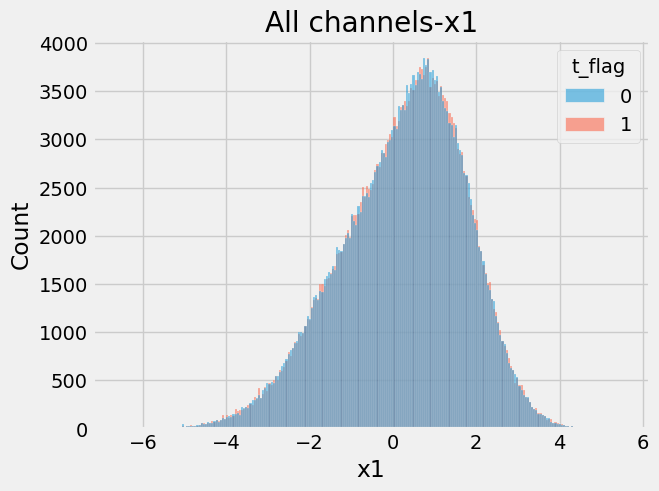

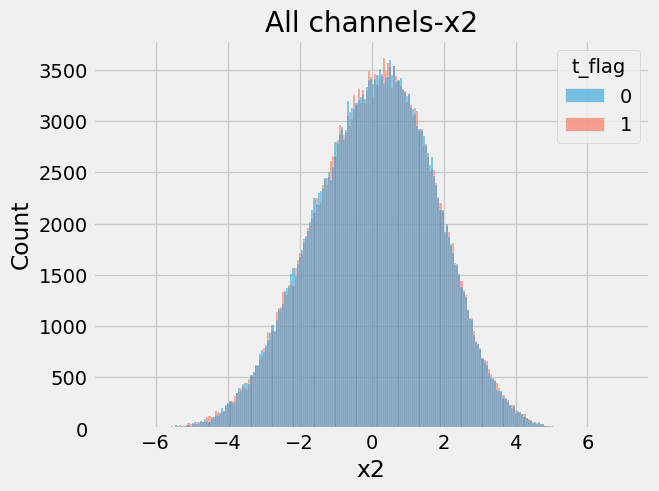

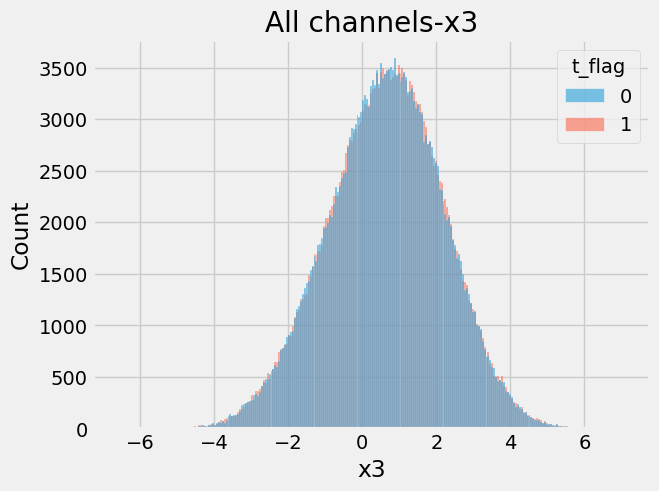

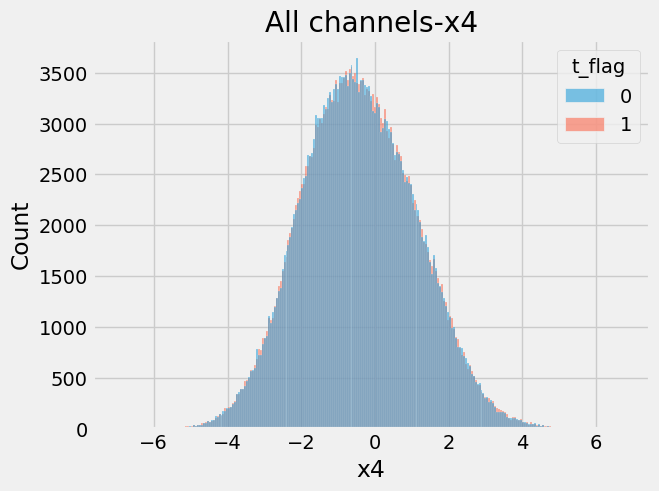

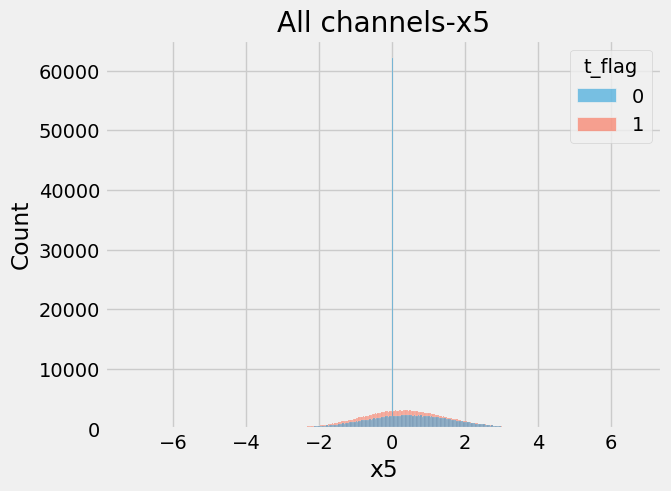

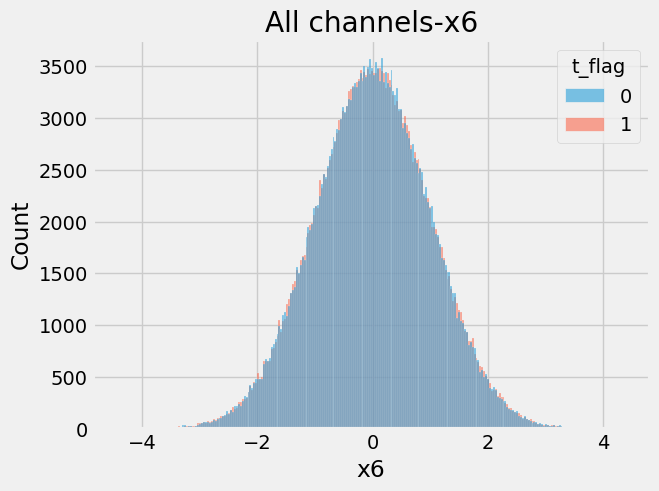

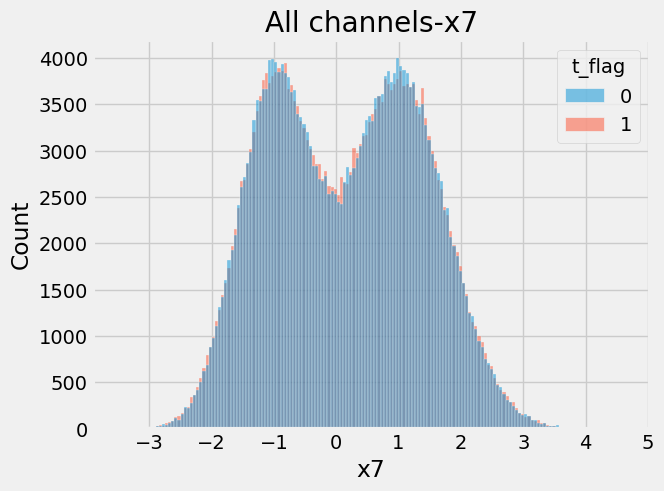

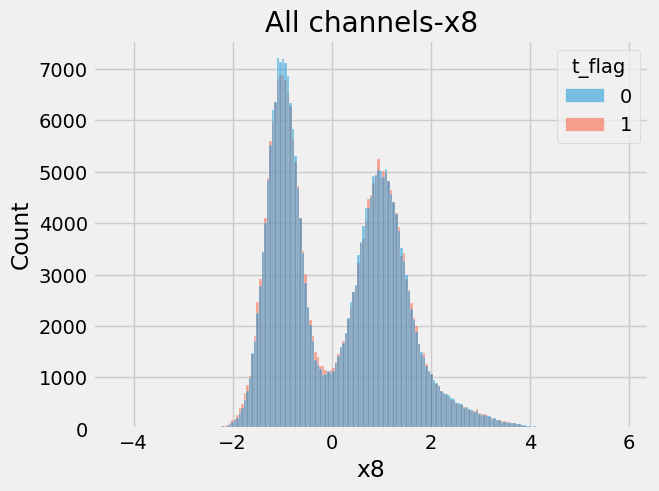

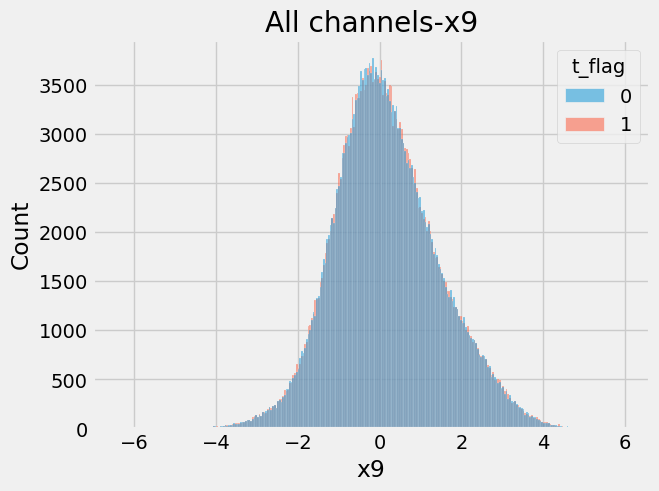

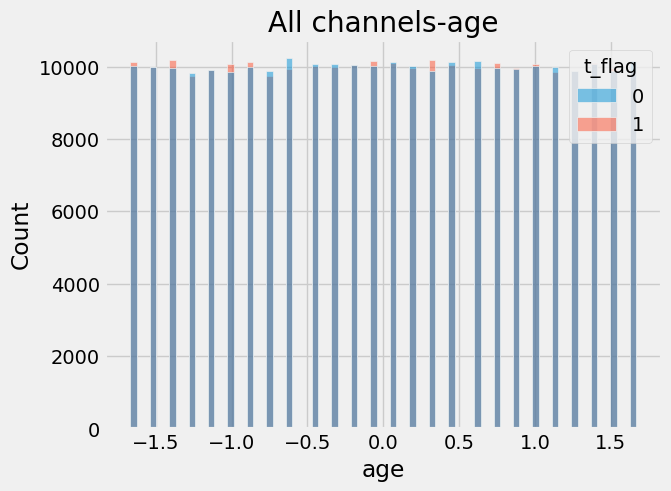

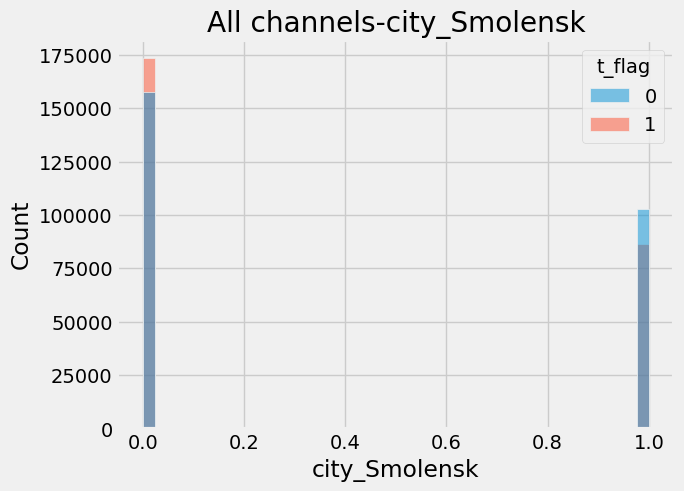

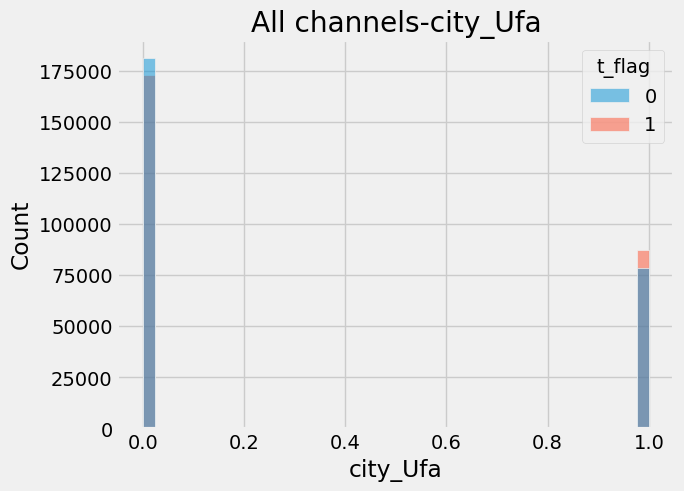

In [110]:
x_names = ['x1','x2','x3','x4','x5','x6','x7','x8','x9', 'age','city_Smolensk', 'city_Ufa']
for col in x_names:
    sns.histplot(data = df, x=col, hue='t_flag').set_title('All channels-'+col)
    plt.show()

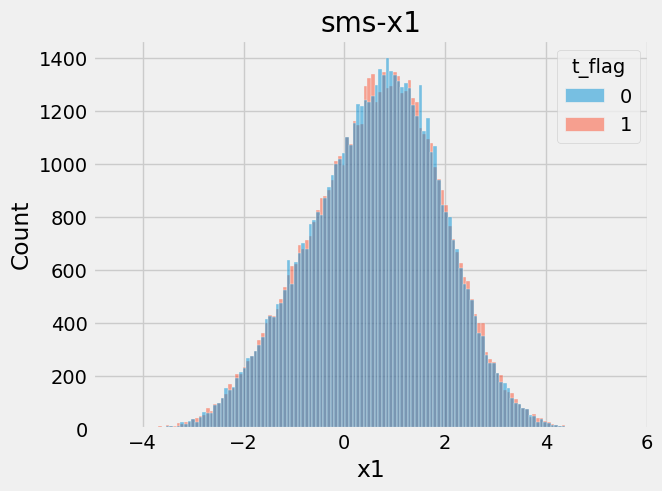

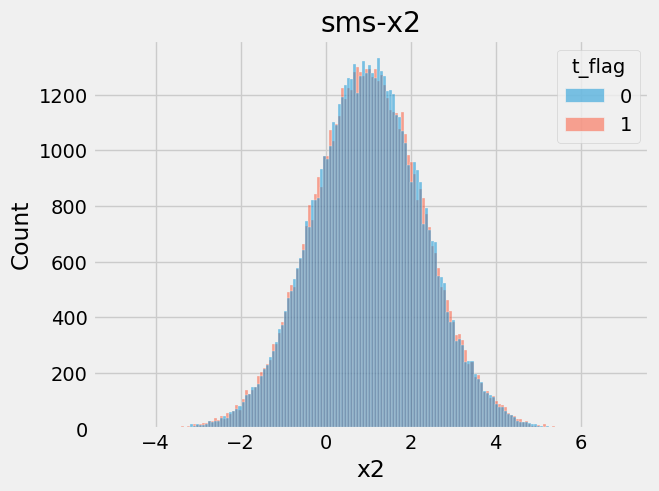

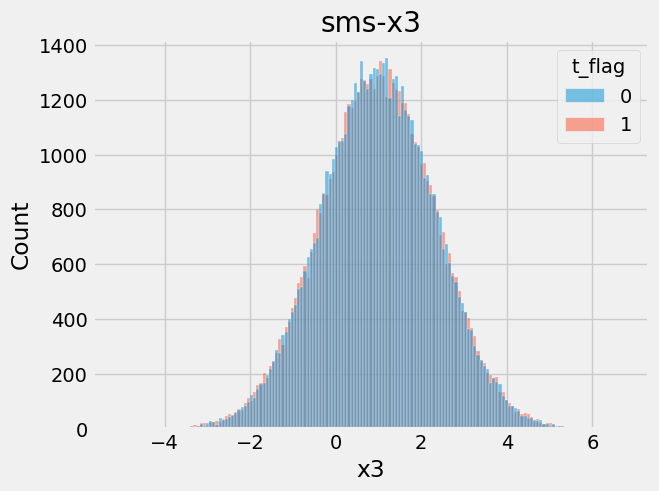

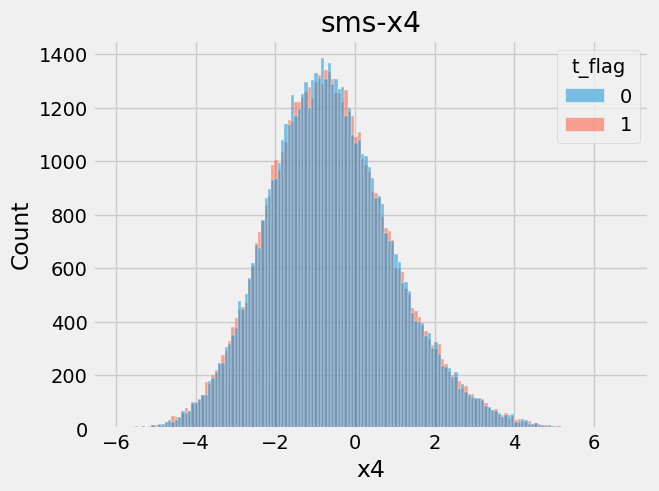

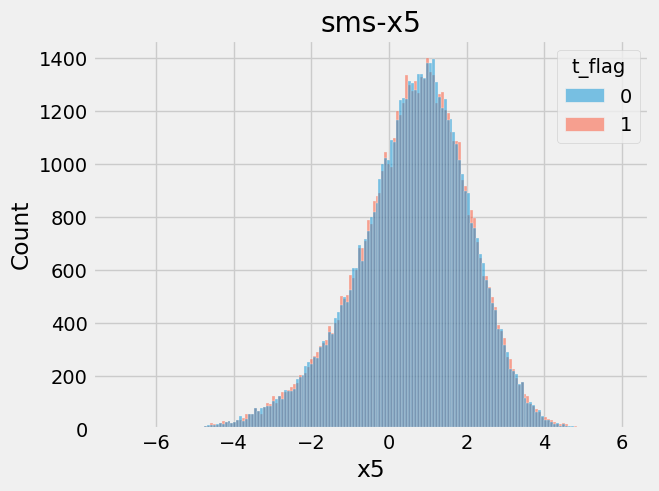

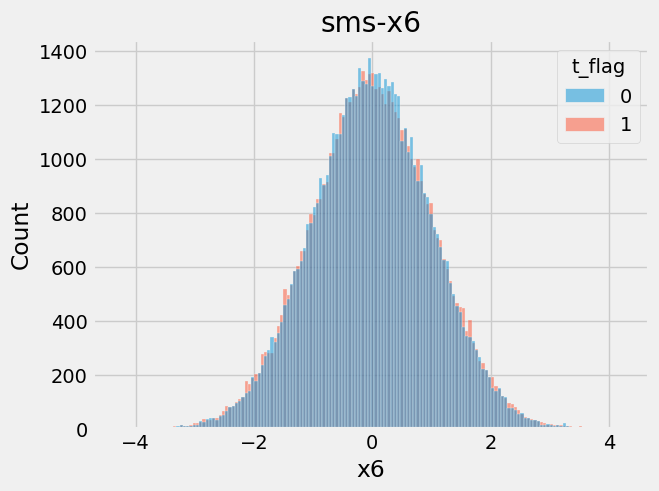

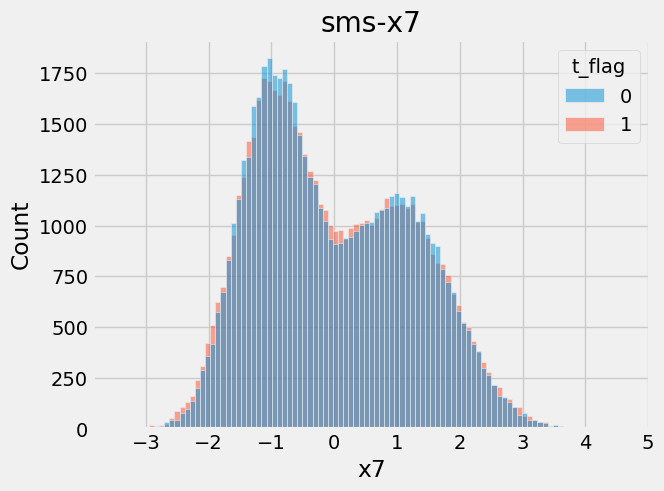

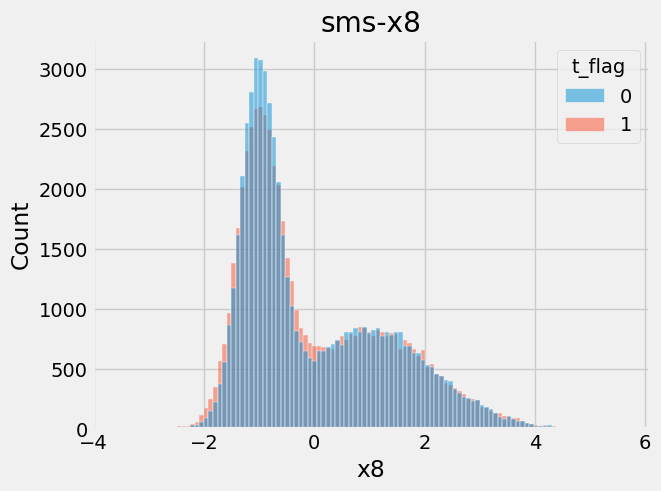

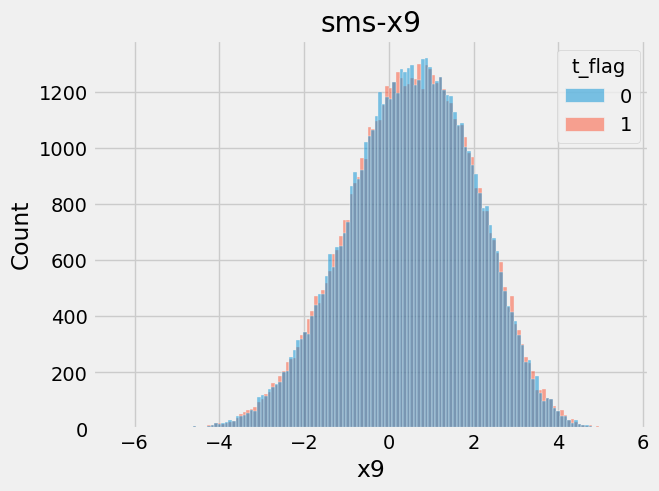

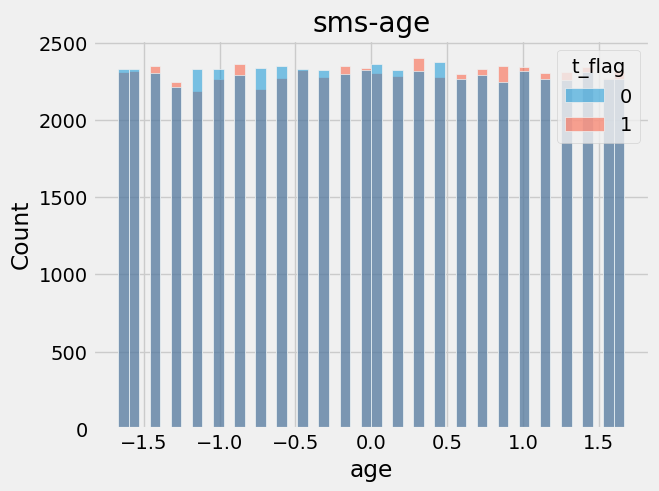

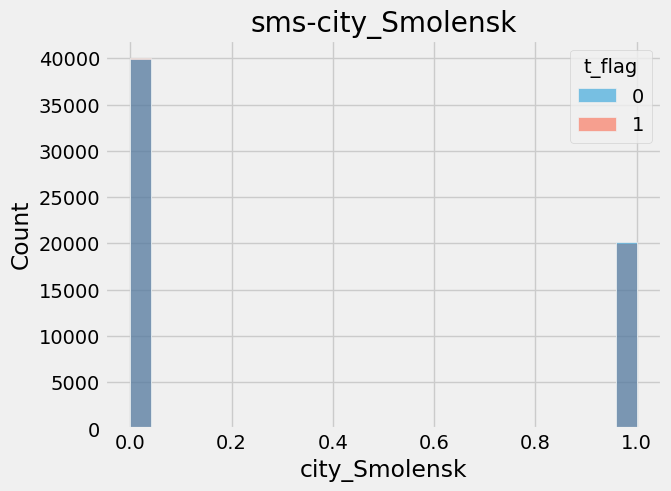

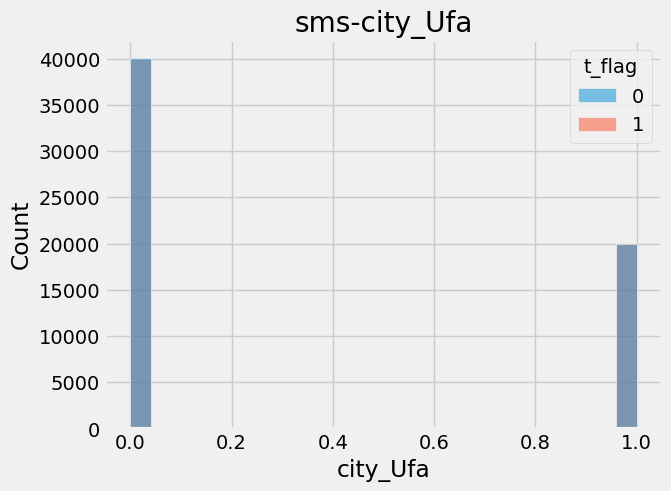

In [111]:
for col in x_names:
    sns.histplot(data = df[df['channel'] == 'sms'], x=col, hue='t_flag').set_title('sms-'+col)
    plt.show()

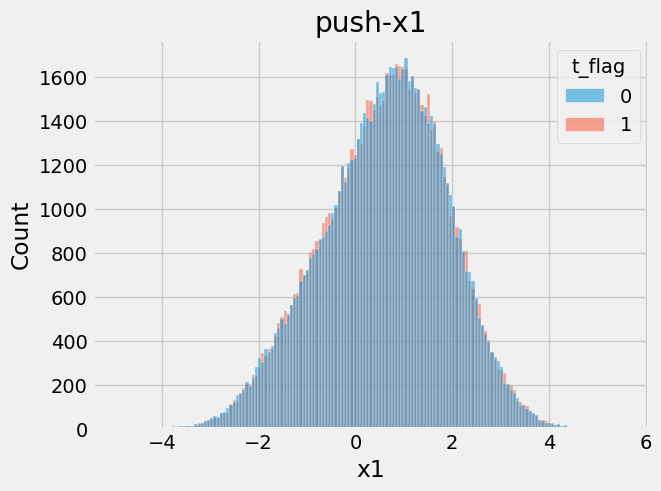

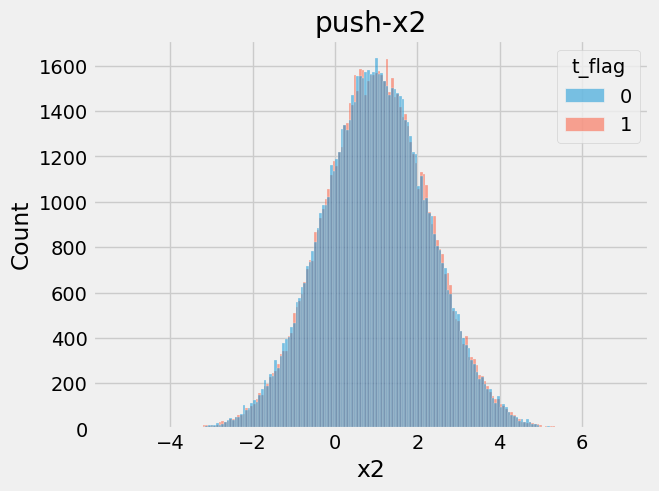

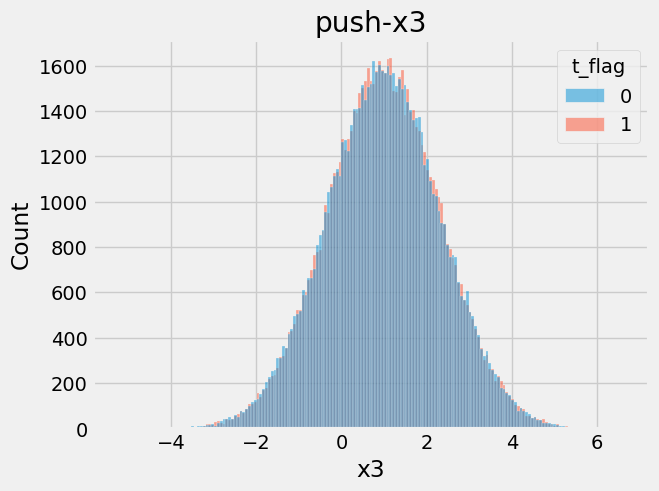

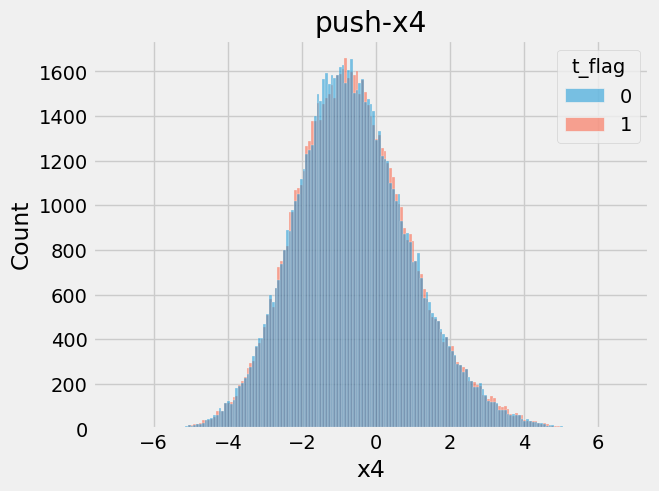

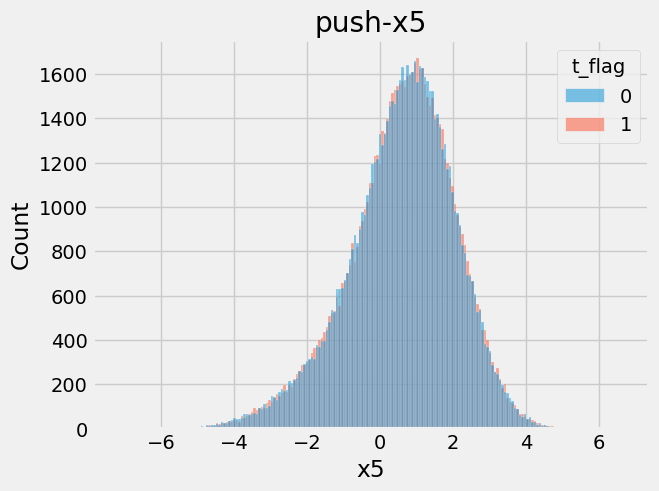

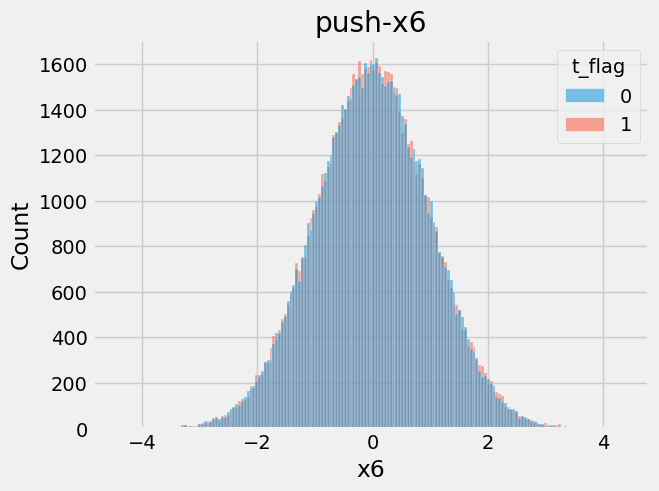

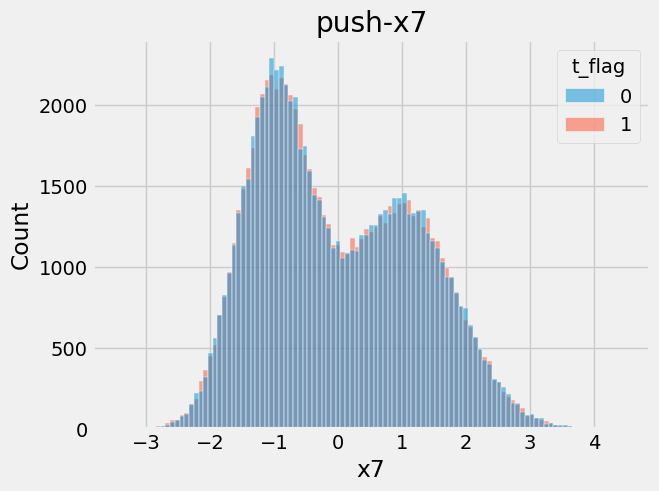

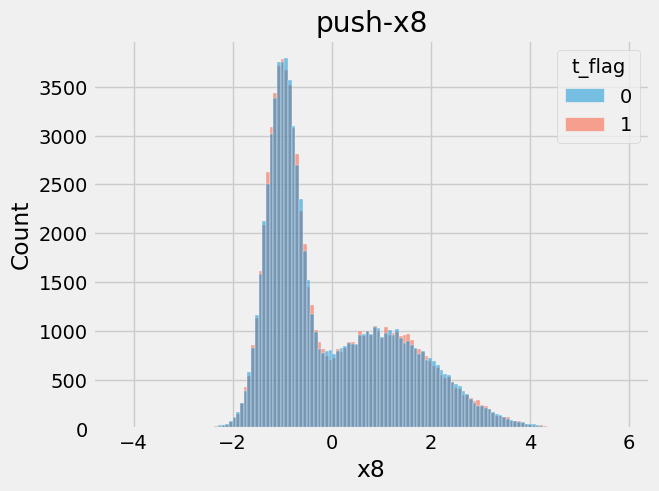

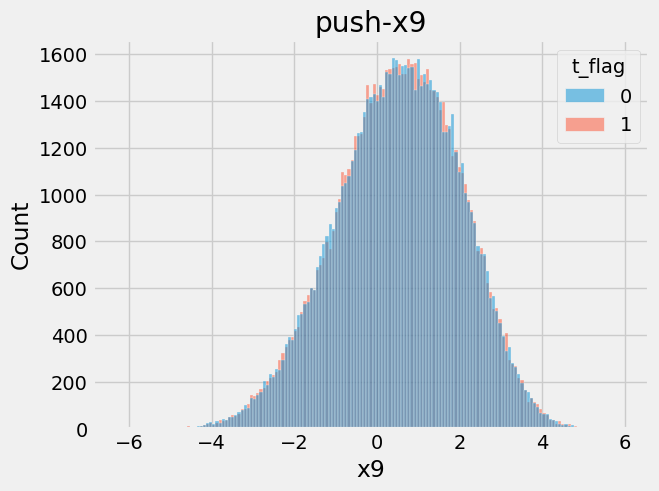

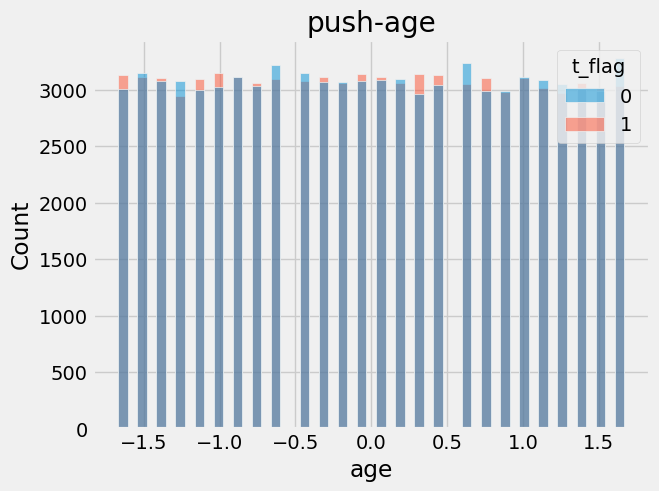

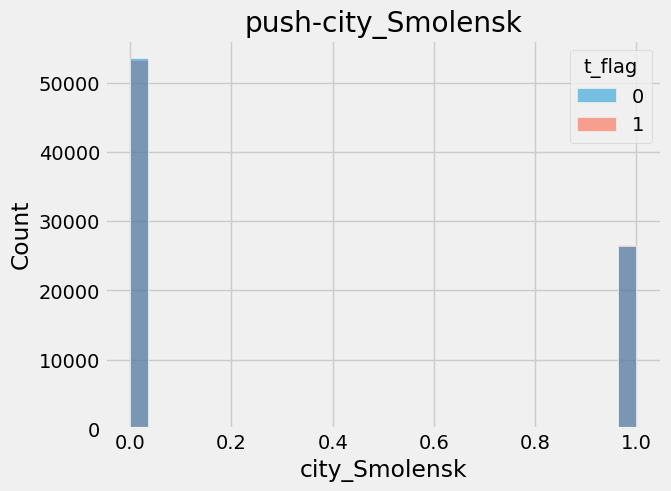

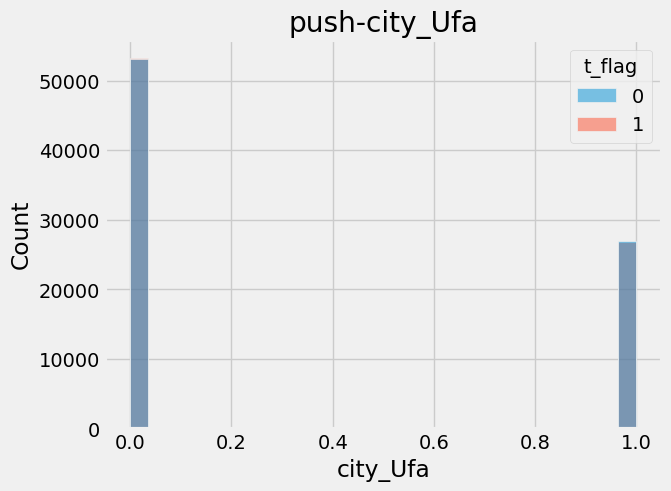

In [112]:
for col in x_names:
    sns.histplot(data = df[df['channel'] == 'push'], x=col, hue='t_flag').set_title('push-'+col)
    plt.show()

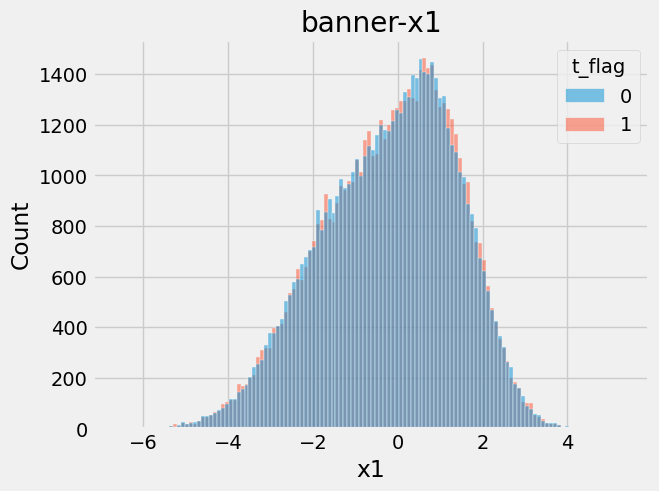

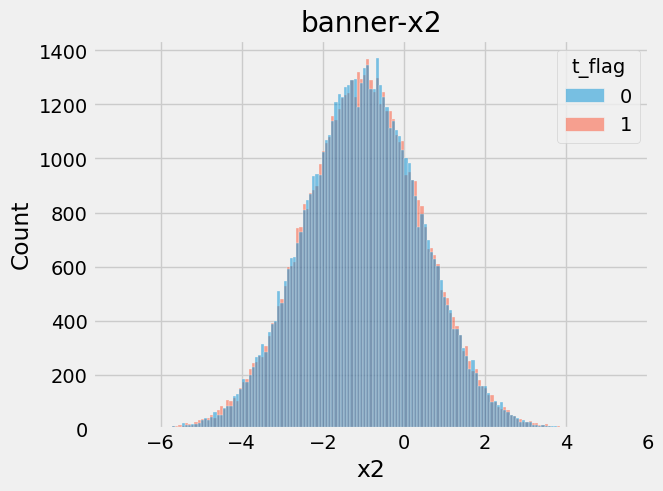

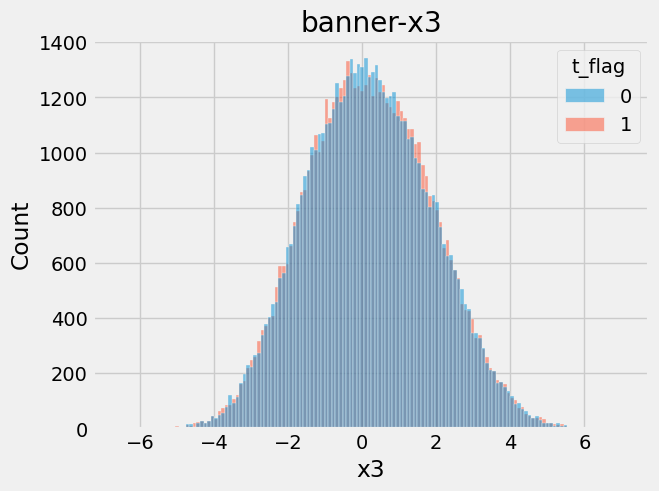

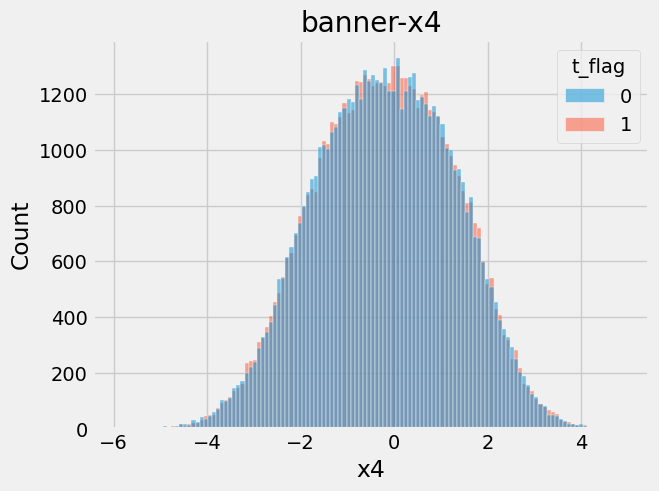

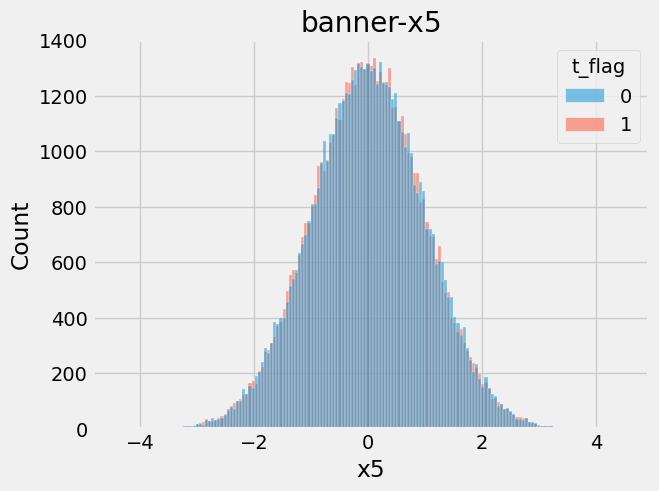

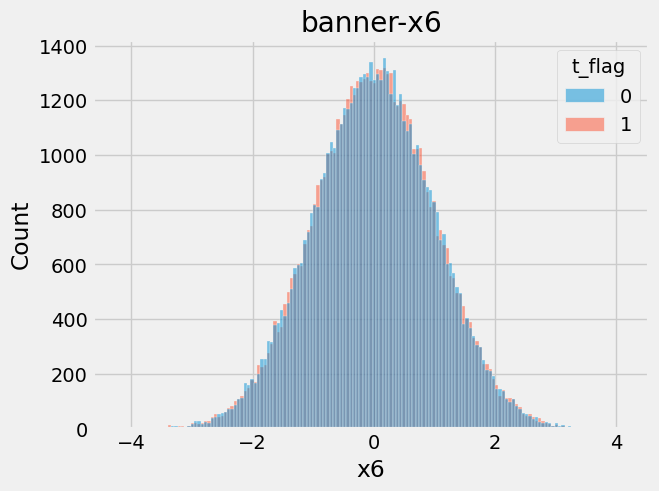

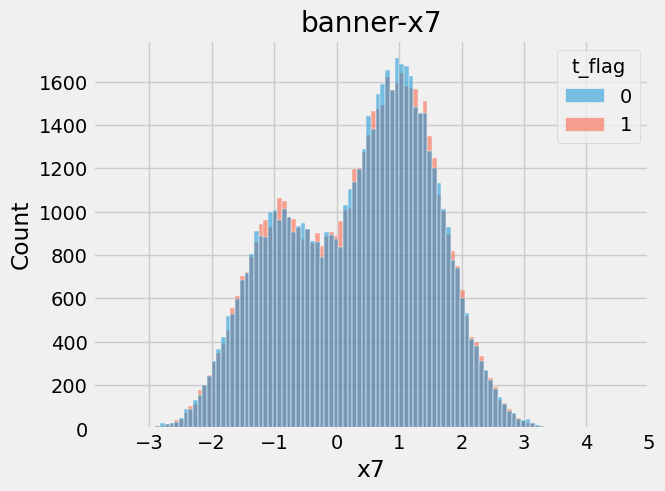

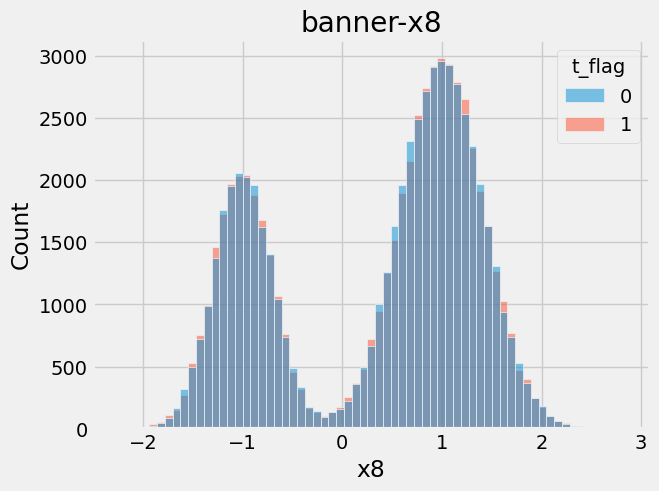

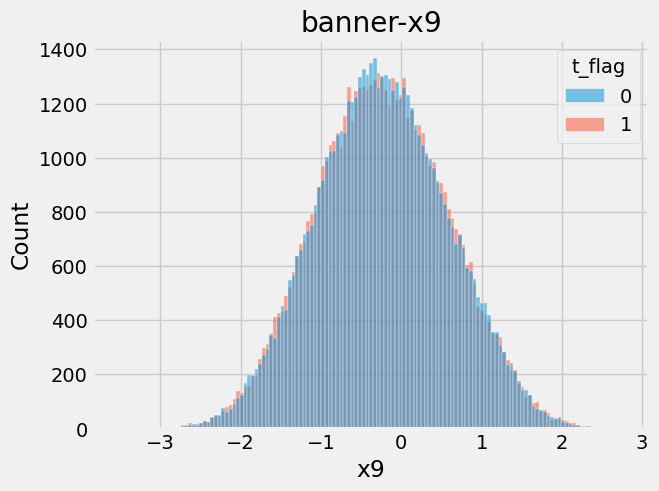

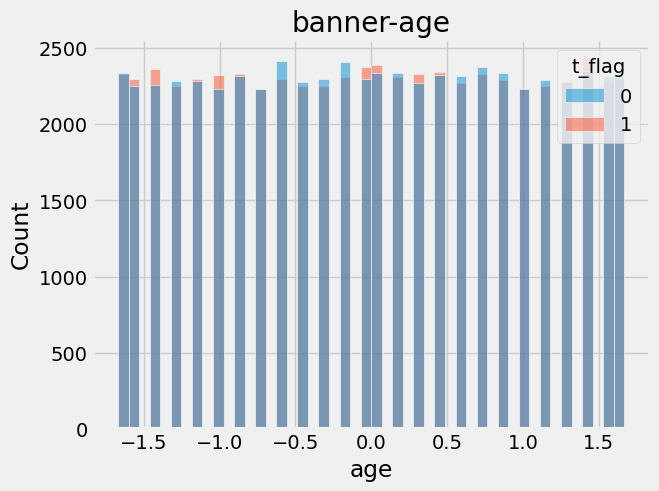

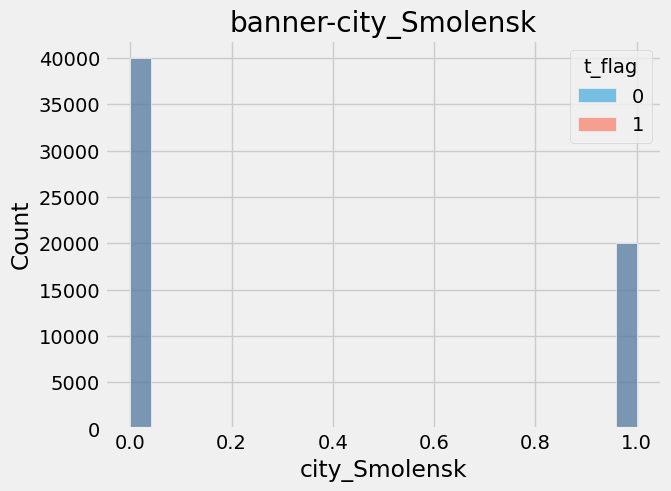

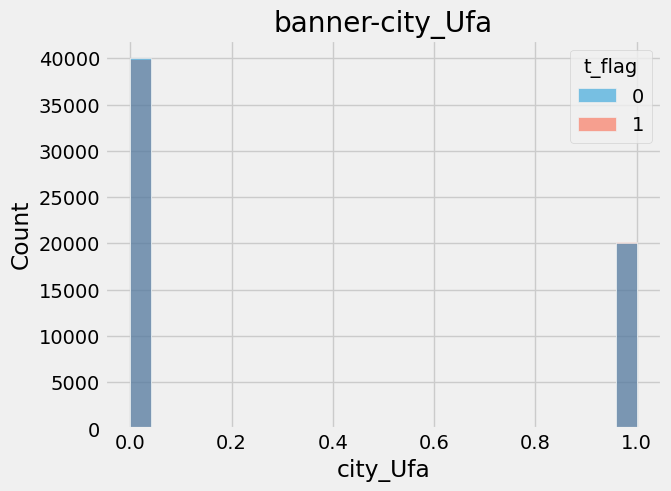

In [113]:
for col in x_names:
    sns.histplot(data = df[df['channel'] == 'banner'], x=col, hue='t_flag').set_title('banner-'+col)
    plt.show()

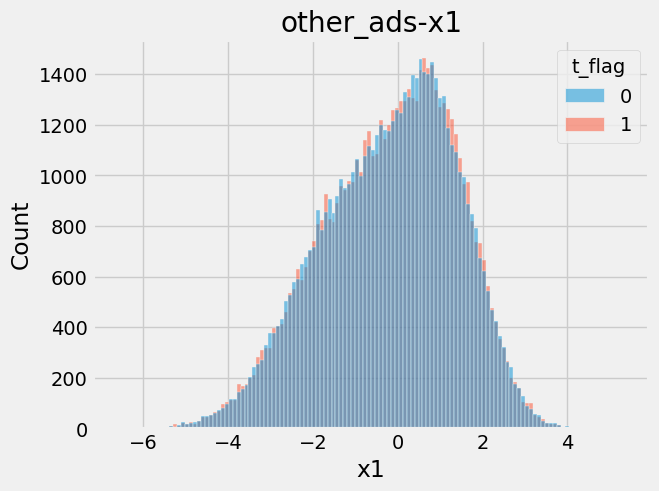

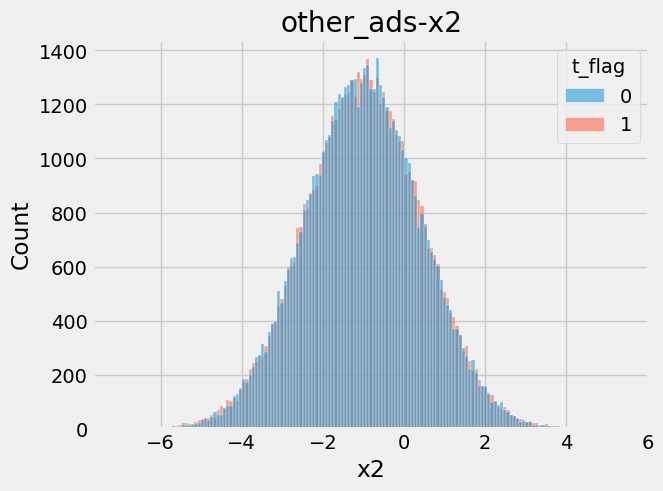

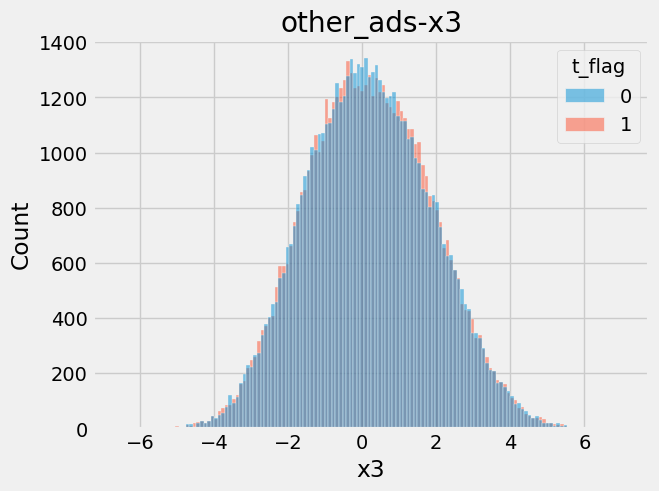

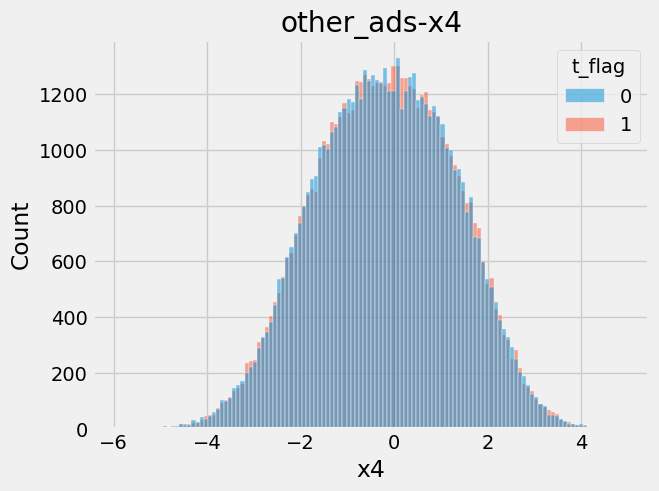

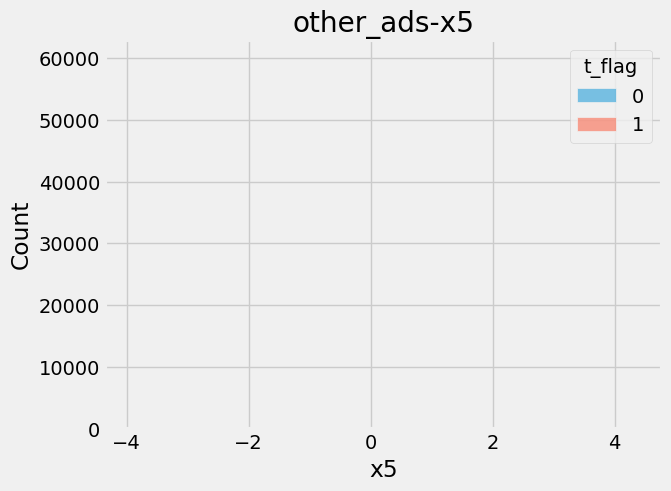

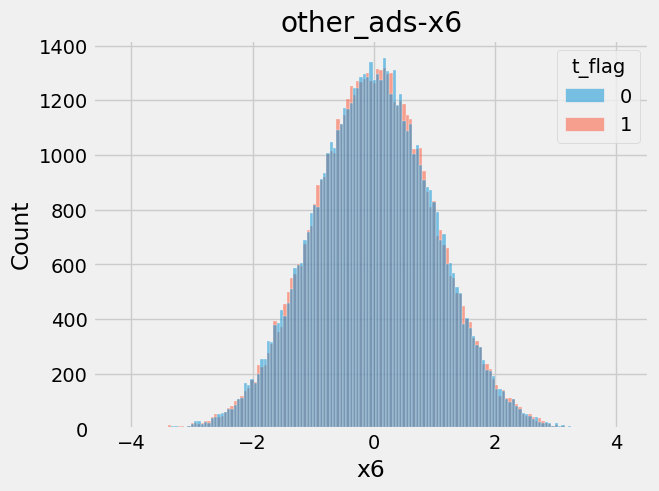

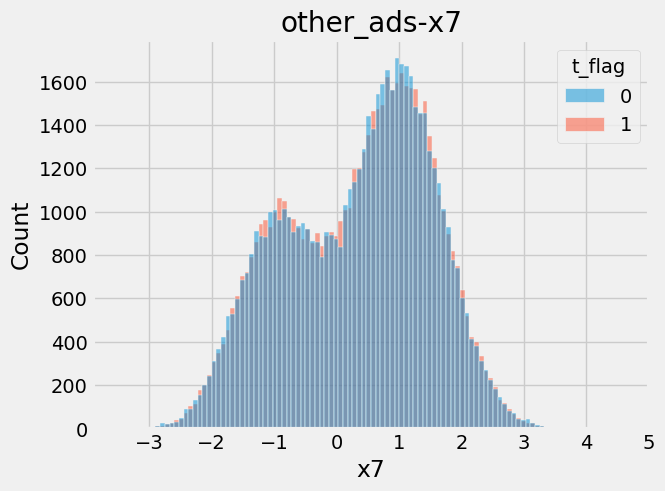

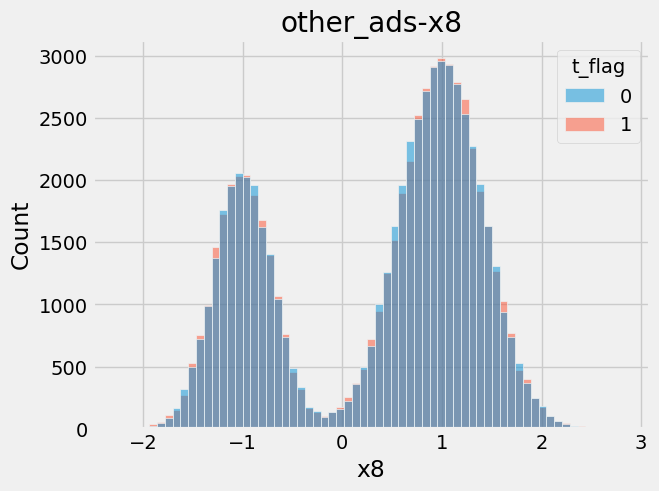

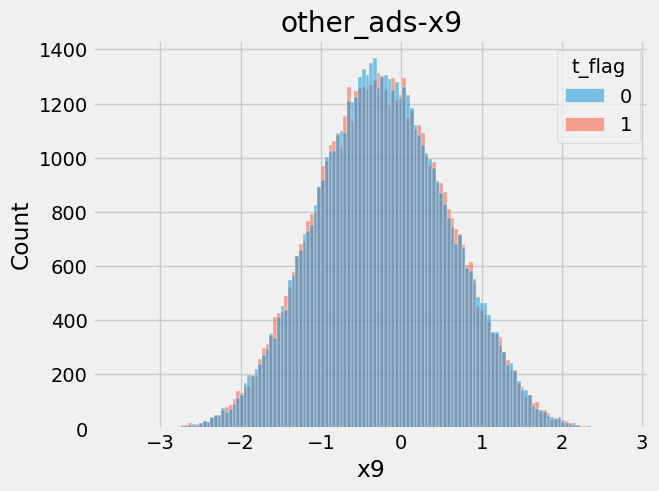

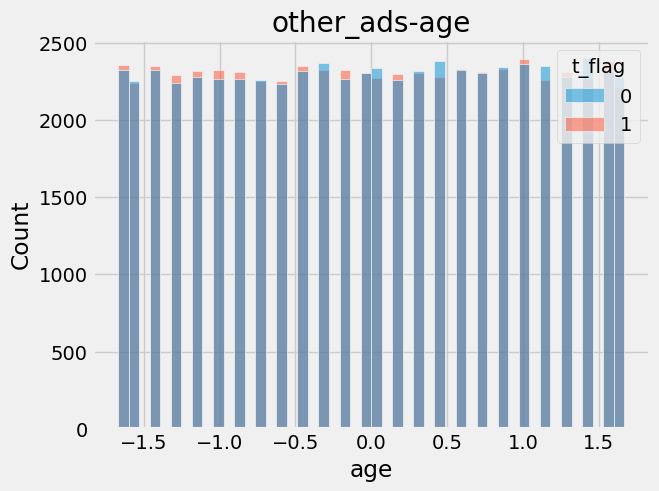

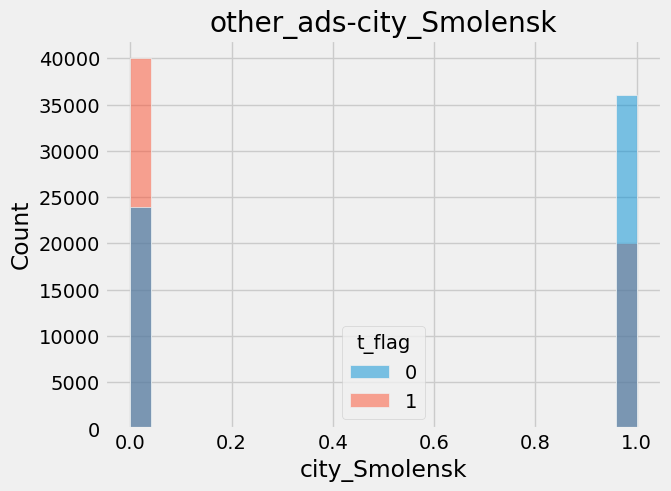

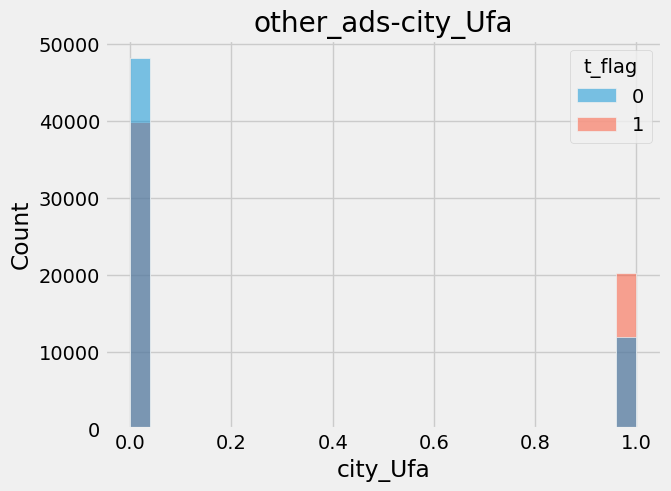

In [114]:
for col in x_names:
    sns.histplot(data = df[df['channel'] == 'other_ads'], x=col, hue='t_flag').set_title('other_ads-'+col)
    plt.show()

In [115]:
# позаимствовано тут: https://www.nannyml.com/blog/population-stability-index-psi

def calculate_psi(reference, monitored, bins=None):
    """
    Calculate the Population Stability Index (PSI) between a reference dataset and a monitored dataset.

    Parameters:
    reference (numpy.array): The reference dataset, representing the baseline distribution.
    monitored (numpy.array): The monitored dataset, representing the distribution to compare against the reference.
    bins (int, optional): The number of bins to use for the histograms. If set to None, Doane's formula will be used to calculate the number of bins. Default is None.

    Returns:
    float: The calculated PSI value. A higher value indicates greater divergence between the two distributions.
    """
    # Get the full dataset
    full_dataset = np.concatenate((reference, monitored))

    # If bins is not parametrized, use Doane's formula for calculating number of bins
    if bins is None:
        _, bin_edges = np.histogram(full_dataset, bins="doane")
    else:  # If number of bins is specified
        bin_edges = np.linspace(min(min(reference), min(monitored)), max(max(reference), max(monitored)), bins + 1)

    # Calculate the histogram for each dataset
    reference_hist, _ = np.histogram(reference, bins=bin_edges)
    monitored_hist, _ = np.histogram(monitored, bins=bin_edges)

    # Convert histograms to proportions
    reference_proportions = reference_hist / np.sum(reference_hist)
    monitored_proportions = monitored_hist / np.sum(monitored_hist)

    # Replace zeroes to avoid division by zero or log of zero errors
    monitored_proportions = np.where(monitored_proportions == 0, 1e-6, monitored_proportions)
    reference_proportions = np.where(reference_proportions == 0, 1e-6, reference_proportions)

    # Calculate PSI
    psi_values = (monitored_proportions - reference_proportions) * np.log(monitored_proportions / reference_proportions)
    psi = np.sum(psi_values)

    return psi

In [116]:
df_1 = df.drop(columns = ['target'])

In [117]:
for col in x_names:
    reference = df_1[df_1.t_flag == 0][col]
    monitored = df_1[df_1.t_flag == 1][col]
    psi_calc = calculate_psi(reference, monitored)
    print(f'psi для признака {col} равно {psi_calc}')

psi для признака x1 равно 0.00024622022435391285
psi для признака x2 равно 0.00024940196505150416
psi для признака x3 равно 0.0002192140973827327
psi для признака x4 равно 0.00016628649365732395
psi для признака x5 равно 0.19235954097355823
psi для признака x6 равно 0.0001735285480444165
psi для признака x7 равно 0.00037619268334093794
psi для признака x8 равно 0.0010840483038245953
psi для признака x9 равно 0.0001968439219926995
psi для признака age равно 0.00015734362689715086
psi для признака city_Smolensk равно 0.016373908653206554
psi для признака city_Ufa равно 0.004730205256413647


In [118]:
channel_names = ['sms', 'banner', 'push', 'other_ads']
for ch in channel_names:
    print('-'*20)
    print(f'{ch} - кампания')
    for col in x_names:
        df_2 = df_1[df_1['channel'] == ch]
        reference = df_2[df_2.t_flag == 0][col]
        monitored = df_2[df_2.t_flag == 1][col]
        psi_calc = calculate_psi(reference, monitored)
        print(f'psi для признака {col} равно {psi_calc}')
    print('-'*20)

--------------------
sms - кампания
psi для признака x1 равно 0.000481767930618682
psi для признака x2 равно 0.00043228130849175717
psi для признака x3 равно 0.00042265515740689614
psi для признака x4 равно 0.0003789487257176194
psi для признака x5 равно 0.00042887448802985176
psi для признака x6 равно 0.0013663472684978706
psi для признака x7 равно 0.0026520855416970403
psi для признака x8 равно 0.012753023463428237
psi для признака x9 равно 0.00042735699670104927
psi для признака age равно 0.0006226054039621886
psi для признака city_Smolensk равно 2.0446933808303334e-05
psi для признака city_Ufa равно 1.1753490874880498e-05
--------------------
--------------------
banner - кампания
psi для признака x1 равно 0.0006570566181758625
psi для признака x2 равно 0.0006997727214135557
psi для признака x3 равно 0.0008550194013073257
psi для признака x4 равно 0.0004912867069748495
psi для признака x5 равно 0.0004899300317746433
psi для признака x6 равно 0.0003858249958942338
psi для признака x


---

### Выводы

*   Для кампании other_ads нужно исключить признаки х5 и city, psi > 0.1 и неравномерные распределения по графикам.
*   К признаку age применен StandardScaler, так признак лучше соответствует остальным по распределению.
* Признак City закодирован OHE, соответственно на выходе у нас два новых бинарных признака.
* В остальном признаки подходят для дальнейшего построения моделей
* Кампанию sms решено исключить из моделирования, хотя признаки в ней распределены равномерно, но природа ошибки в данных не ясна. Скорее всего проблема в выборке контрольной группы, которая совпадает с целевой из push. Я бы предположил, что целевая и контрольная группы также могли быть перепутаны.


---




<h2> 3. Построение моделей и оценка их качества (14 баллов)</h2>

Постройте Uplift модели по собранным кампаниям, проведите тюнинг гиперпараметров и оцените их качество (qini score). Для каждой модели также постройте qini-curve.

**Комментарий по заданиям и оцениванию:**

* Реализован только подход Solomodel без дополнительных библиотек и калибровок  - **1 балл**

* Реализован Solomodel или Twomodel через Sklift или CausalML - **2 балла**

* Учтена калибровка Metalearner'ах - **2 балла**

* Корректно реализован ClassTransformation - **2 балла**

* Реализован UpliftRandomForest - **4 балла**

* Использованы пайплайны в Sklift - **2 балла**

* Реализован тюнинг ( Gridsearch \ Optuna ) - **1 балл**

In [119]:
banner = df[df['channel'] == 'banner'].drop(columns=['channel', 'user_id','report_dt']).reset_index(drop=True)
push = df[df['channel'] == 'push'].drop(columns=['channel', 'user_id','report_dt']).reset_index(drop=True)
other_ads = df[df['channel'] == 'other_ads'].drop(columns=['x5', 'city_Smolensk', 'city_Ufa', 'channel', 'user_id','report_dt']).reset_index(drop=True)

In [120]:
banner.to_csv('banner.csv', index=False)
push.to_csv('push.csv', index=False)
other_ads.to_csv('other_ads.csv', index=False)

In [121]:
RANDOM_STATE = 42


## Banner training

SoloModel baseline Qini AUC: 0.20615588715888808


<Figure size 800x600 with 0 Axes>

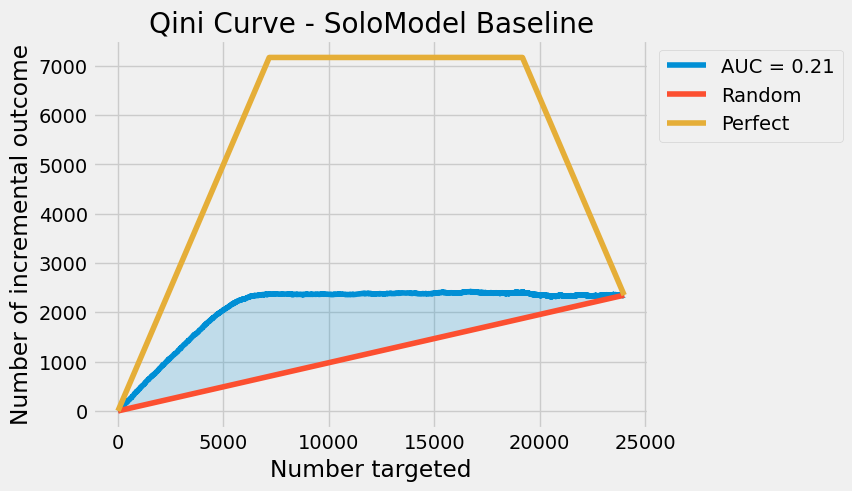

In [261]:
X = banner.drop(columns=['target', 't_flag'])
y = banner['target']
treatment = banner['t_flag']

X_train, X_test, y_train, y_test, treat_train, treat_test = train_test_split(
    X, y, treatment, test_size=0.2, random_state=RANDOM_STATE, stratify=treatment
)

solo_pipeline = Pipeline([
    ('scaler', MinMaxScaler()),
    ('clf', LogisticRegression(solver='liblinear', random_state=RANDOM_STATE))
])
solo_model = SoloModel(estimator=solo_pipeline)
solo_model.fit(X_train, y_train, treatment=treat_train)
uplift_pred_solo = solo_model.predict(X_test)
qini_solo = qini_auc_score(y_test, uplift_pred_solo, treat_test)
print("SoloModel baseline Qini AUC:", qini_solo)
plt.figure(figsize=(8,6))
plot_qini_curve(y_test, uplift_pred_solo, treat_test)
plt.title("Qini Curve - SoloModel Baseline")
plt.show()

TwoModels Qini AUC: 0.21055629287055228


<Figure size 800x600 with 0 Axes>

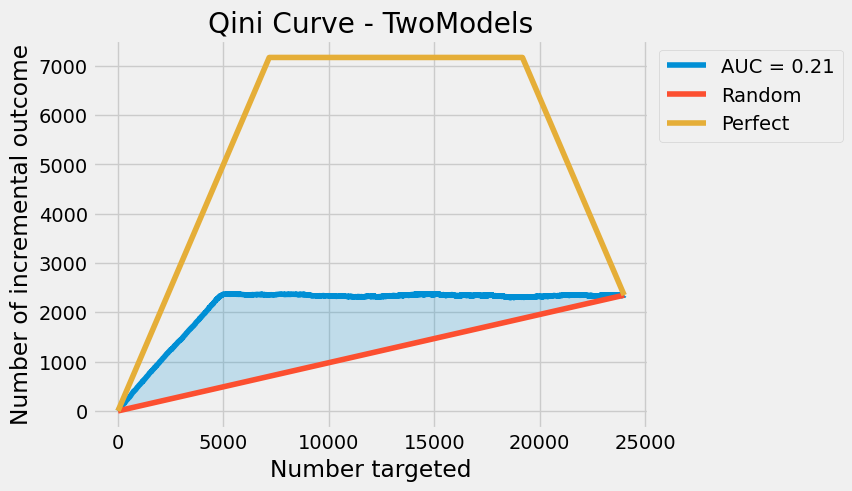

In [240]:
pipeline_control = Pipeline([
    ('scaler', MinMaxScaler()),
    ('clf', LogisticRegression(solver='liblinear', random_state=RANDOM_STATE))
])
pipeline_treatment = Pipeline([
    ('scaler', MinMaxScaler()),
    ('clf', LogisticRegression(solver='liblinear', random_state=RANDOM_STATE))
])
two_models = TwoModels(pipeline_treatment, pipeline_control)
two_models.fit(X_train, y_train, treatment=treat_train)
uplift_pred_two = two_models.predict(X_test)
qini_two = qini_auc_score(y_test, uplift_pred_two, treat_test)
print("TwoModels Qini AUC:", qini_two)
plt.figure(figsize=(8,6))
plot_qini_curve(y_test, uplift_pred_two, treat_test)
plt.title("Qini Curve - TwoModels")
plt.show()

ClassTransformation Qini AUC: 0.2174633739132664


<Figure size 800x600 with 0 Axes>

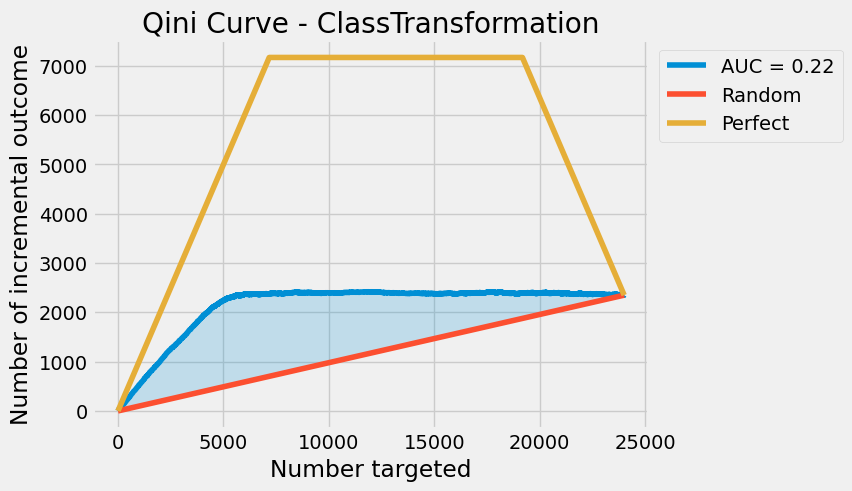

In [262]:
clf_calibrated = CalibratedClassifierCV(
    base_estimator=LogisticRegression(solver='liblinear', random_state=RANDOM_STATE),
    cv=3,
    method='sigmoid'
)
class_trans_pipeline = Pipeline([
    ('scaler', MinMaxScaler()),
    ('clf', clf_calibrated)
])

class_trans_model = ClassTransformation(estimator=class_trans_pipeline)
class_trans_model.fit(X_train, y_train, treatment=treat_train)
uplift_pred_class = class_trans_model.predict(X_test)
qini_class = qini_auc_score(y_test, uplift_pred_class, treat_test)
print("ClassTransformation Qini AUC:", qini_class)
plt.figure(figsize=(8,6))
plot_qini_curve(y_test, uplift_pred_class, treat_test)
plt.title("Qini Curve - ClassTransformation")
plt.show()


In [183]:
def objective(trial):
    C = trial.suggest_loguniform('C', 1e-4, 1e2)
    pipeline_tune = Pipeline([
        ('scaler', MinMaxScaler()),
        ('clf', CalibratedClassifierCV(
            base_estimator=LogisticRegression(C=C, solver='liblinear', random_state=RANDOM_STATE),
            cv=3,
            method='sigmoid'
        ))
    ])
    solo_model_tune = SoloModel(estimator=pipeline_tune)

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    scores = []
    for train_idx, val_idx in cv.split(X_train, treat_train):
        X_cv_train, X_cv_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_cv_train, y_cv_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        treat_cv_train, treat_cv_val = treat_train.iloc[train_idx], treat_train.iloc[val_idx]
        solo_model_tune.fit(X_cv_train, y_cv_train, treatment=treat_cv_train)
        uplift_pred_cv = solo_model_tune.predict(X_cv_val)
        score = qini_auc_score(y_cv_val, uplift_pred_cv, treat_cv_val)
        scores.append(score)
    return np.mean(scores)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20)

[I 2025-03-02 18:47:53,506] A new study created in memory with name: no-name-c17d67de-90f0-4745-a7ab-0331329b5dae
[I 2025-03-02 18:48:05,227] Trial 0 finished with value: 0.19774517977788666 and parameters: {'C': 1.4201064817640763}. Best is trial 0 with value: 0.19774517977788666.
[I 2025-03-02 18:48:18,038] Trial 1 finished with value: 0.197939918469401 and parameters: {'C': 1.6195575034622847}. Best is trial 1 with value: 0.197939918469401.
[I 2025-03-02 18:48:28,374] Trial 2 finished with value: 0.1988827446326799 and parameters: {'C': 5.82003430322168}. Best is trial 2 with value: 0.1988827446326799.
[I 2025-03-02 18:48:31,574] Trial 3 finished with value: 0.09742428731959651 and parameters: {'C': 0.0010123536475211154}. Best is trial 2 with value: 0.1988827446326799.
[I 2025-03-02 18:48:39,206] Trial 4 finished with value: 0.18226454319153945 and parameters: {'C': 0.10255469073706257}. Best is trial 2 with value: 0.1988827446326799.
[I 2025-03-02 18:48:47,971] Trial 5 finished wi

AttributeError: 'Study' object has no attribute 'best_params_'

In [184]:
print("Best hyperparameters from Optuna:", study.best_params)
print("Best CV Qini AUC (Optuna SoloModel):", study.best_value)

Best hyperparameters from Optuna: {'C': 77.87273242465498}
Best CV Qini AUC (Optuna SoloModel): 0.19912811008505987


UpliftRandomForest Qini AUC: 0.21759889527744436


<Figure size 800x600 with 0 Axes>

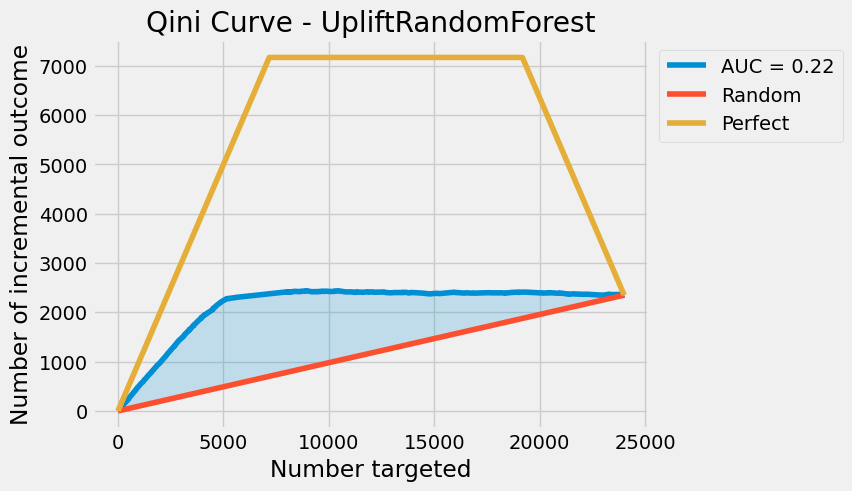

In [214]:
uplift_rf = UpliftRandomForestClassifier(
    control_name='0',
    random_state=RANDOM_STATE
)


uplift_rf.fit(X=X_train.values,
                  y=y_train.values,
                  treatment=treat_train.astype(str).values)
uplift_pred_rf = uplift_rf.predict(X=X_test.values)
qini_rf = qini_auc_score(y_true=y_test,
                 uplift=uplift_pred_rf.reshape(-1),
                 treatment=treat_test.astype('int'))

print("UpliftRandomForest Qini AUC:", qini_rf)
plt.figure(figsize=(8,6))
plot_qini_curve(y_true=y_test,
                  uplift=pd.Series(uplift_pred_rf.reshape(-1), index=X_test.index),
                  treatment=treat_test.astype(int))
plt.title("Qini Curve - UpliftRandomForest")
plt.show()

In [263]:
model_banner = class_trans_model

## Push training

SoloModel baseline Qini AUC: 0.22146488967049033


<Figure size 800x600 with 0 Axes>

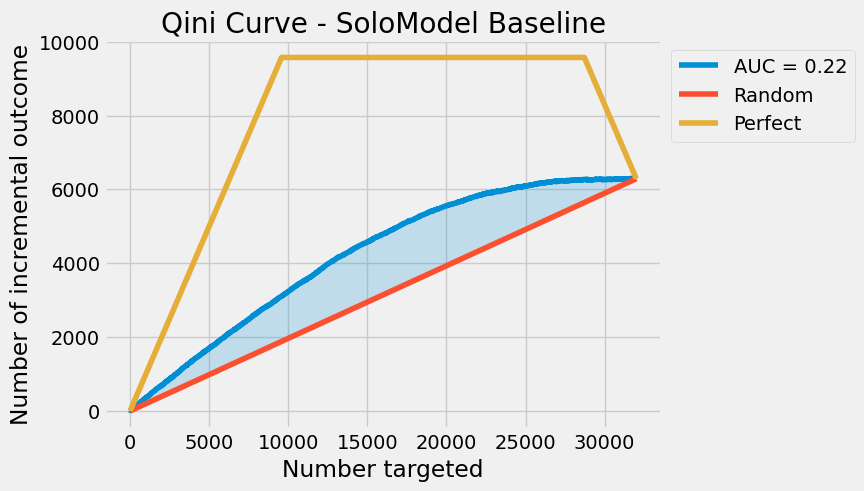

In [264]:
X = push.drop(columns=['target', 't_flag'])
y = push['target']
treatment = push['t_flag']

X_train, X_test, y_train, y_test, treat_train, treat_test = train_test_split(
    X, y, treatment, test_size=0.2, random_state=RANDOM_STATE, stratify=treatment
)

solo_pipeline = Pipeline([
    ('scaler', MinMaxScaler()),
    ('clf', LogisticRegression(solver='liblinear', random_state=RANDOM_STATE))
])
solo_model = SoloModel(estimator=solo_pipeline)
solo_model.fit(X_train, y_train, treatment=treat_train)
uplift_pred_solo = solo_model.predict(X_test)
qini_solo = qini_auc_score(y_test, uplift_pred_solo, treat_test)
print("SoloModel baseline Qini AUC:", qini_solo)
plt.figure(figsize=(8,6))
plot_qini_curve(y_test, uplift_pred_solo, treat_test)
plt.title("Qini Curve - SoloModel Baseline")
plt.show()

TwoModels Qini AUC: 0.3677729160316599


<Figure size 800x600 with 0 Axes>

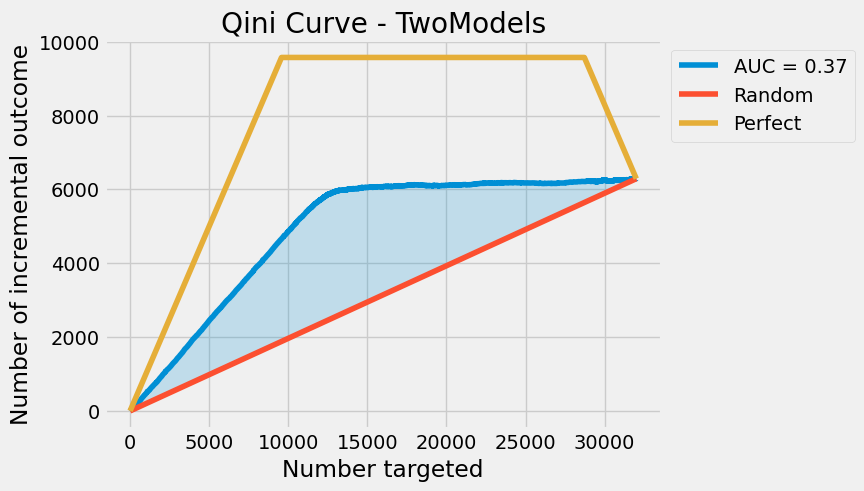

In [243]:
pipeline_control = Pipeline([
    ('scaler', MinMaxScaler()),
    ('clf', LogisticRegression(solver='liblinear', random_state=RANDOM_STATE))
])
pipeline_treatment = Pipeline([
    ('scaler', MinMaxScaler()),
    ('clf', LogisticRegression(solver='liblinear', random_state=RANDOM_STATE))
])
two_models = TwoModels(pipeline_treatment, pipeline_control)
two_models.fit(X_train, y_train, treatment=treat_train)
uplift_pred_two = two_models.predict(X_test)
qini_two = qini_auc_score(y_test, uplift_pred_two, treat_test)
print("TwoModels Qini AUC:", qini_two)
plt.figure(figsize=(8,6))
plot_qini_curve(y_test, uplift_pred_two, treat_test)
plt.title("Qini Curve - TwoModels")
plt.show()

ClassTransformation Qini AUC: 0.34670471667132746


<Figure size 800x600 with 0 Axes>

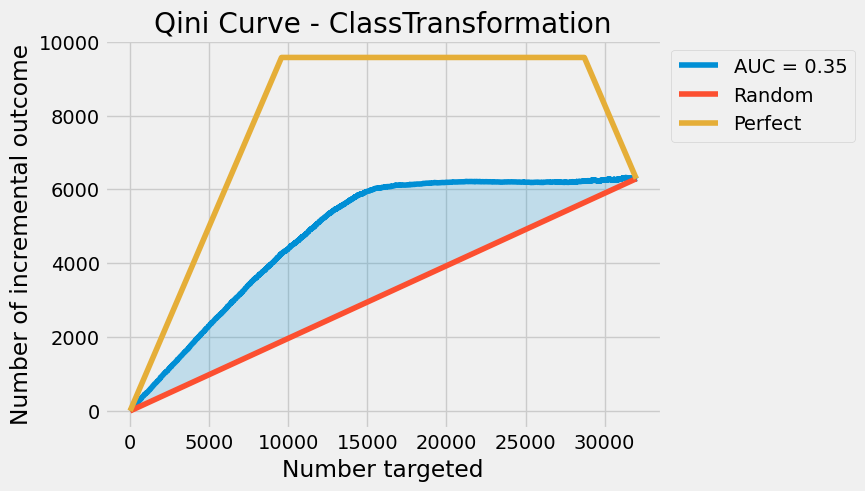

In [265]:
clf_calibrated = CalibratedClassifierCV(
    base_estimator=LogisticRegression(solver='liblinear', random_state=RANDOM_STATE),
    cv=3,
    method='sigmoid'
)
class_trans_pipeline = Pipeline([
    ('scaler', MinMaxScaler()),
    ('clf', clf_calibrated)
])

class_trans_model = ClassTransformation(estimator=class_trans_pipeline)
class_trans_model.fit(X_train, y_train, treatment=treat_train)
uplift_pred_class = class_trans_model.predict(X_test)
qini_class = qini_auc_score(y_test, uplift_pred_class, treat_test)
print("ClassTransformation Qini AUC:", qini_class)
plt.figure(figsize=(8,6))
plot_qini_curve(y_test, uplift_pred_class, treat_test)
plt.title("Qini Curve - ClassTransformation")
plt.show()

In [197]:
def objective(trial):
    C = trial.suggest_loguniform('C', 1e-4, 1e2)
    pipeline_tune = Pipeline([
        ('scaler', MinMaxScaler()),
        ('clf', CalibratedClassifierCV(
            base_estimator=LogisticRegression(C=C, solver='liblinear', random_state=RANDOM_STATE),
            cv=3,
            method='sigmoid'
        ))
    ])
    solo_model_tune = SoloModel(estimator=pipeline_tune)

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    scores = []
    for train_idx, val_idx in cv.split(X_train, treat_train):
        X_cv_train, X_cv_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_cv_train, y_cv_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        treat_cv_train, treat_cv_val = treat_train.iloc[train_idx], treat_train.iloc[val_idx]
        solo_model_tune.fit(X_cv_train, y_cv_train, treatment=treat_cv_train)
        uplift_pred_cv = solo_model_tune.predict(X_cv_val)
        score = qini_auc_score(y_cv_val, uplift_pred_cv, treat_cv_val)
        scores.append(score)
    return np.mean(scores)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20)

[I 2025-03-02 19:11:43,693] A new study created in memory with name: no-name-08324d6a-dbbc-4662-afb6-977005c5998b
[I 2025-03-02 19:11:51,040] Trial 0 finished with value: 0.21713147517808684 and parameters: {'C': 0.33120861995796425}. Best is trial 0 with value: 0.21713147517808684.
[I 2025-03-02 19:11:57,685] Trial 1 finished with value: 0.21674679908316855 and parameters: {'C': 0.10505767395868212}. Best is trial 0 with value: 0.21713147517808684.
[I 2025-03-02 19:12:06,516] Trial 2 finished with value: 0.21750071283917255 and parameters: {'C': 77.87018827980893}. Best is trial 2 with value: 0.21750071283917255.
[I 2025-03-02 19:12:13,072] Trial 3 finished with value: 0.2175001241343184 and parameters: {'C': 66.40368746295101}. Best is trial 2 with value: 0.21750071283917255.
[I 2025-03-02 19:12:24,924] Trial 4 finished with value: 0.21749272639658565 and parameters: {'C': 14.566535201242784}. Best is trial 2 with value: 0.21750071283917255.
[I 2025-03-02 19:12:34,196] Trial 5 finish

In [198]:
print("Best hyperparameters from Optuna:", study.best_params)
print("Best CV Qini AUC (Optuna SoloModel):", study.best_value)

Best hyperparameters from Optuna: {'C': 0.001701544381626561}
Best CV Qini AUC (Optuna SoloModel): 0.2361709230762361


UpliftRandomForest Qini AUC: 0.3701627982893218


<Figure size 800x600 with 0 Axes>

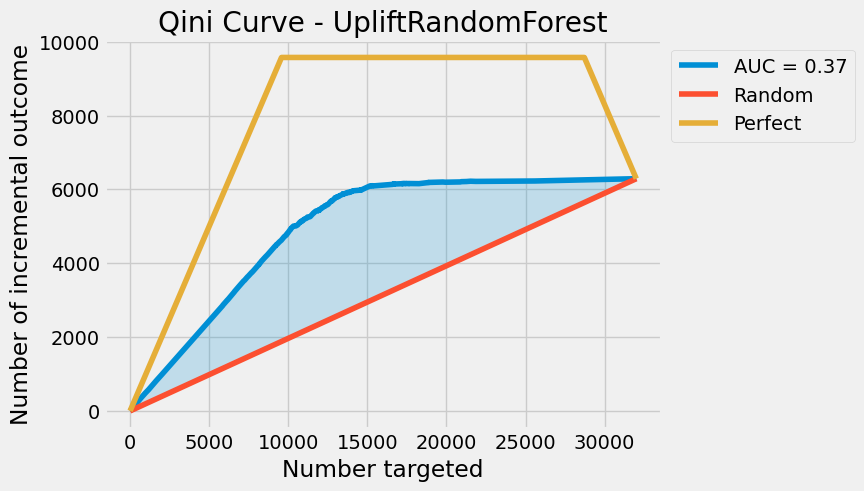

In [217]:
uplift_rf = UpliftRandomForestClassifier(
    control_name='0',
    random_state=RANDOM_STATE
)


uplift_rf.fit(X=X_train.values,
                  y=y_train.values,
                  treatment=treat_train.astype(str).values)
uplift_pred_rf = uplift_rf.predict(X=X_test.values)
qini_rf = qini_auc_score(y_true=y_test,
                 uplift=uplift_pred_rf.reshape(-1),
                 treatment=treat_test.astype('int'))

print("UpliftRandomForest Qini AUC:", qini_rf)
plt.figure(figsize=(8,6))
plot_qini_curve(y_true=y_test,
                  uplift=pd.Series(uplift_pred_rf.reshape(-1), index=X_test.index),
                  treatment=treat_test.astype(int))
plt.title("Qini Curve - UpliftRandomForest")
plt.show()

In [266]:
model_push = study.best_trial

## Other_ads training

SoloModel baseline Qini AUC: 0.19098875982930605


<Figure size 800x600 with 0 Axes>

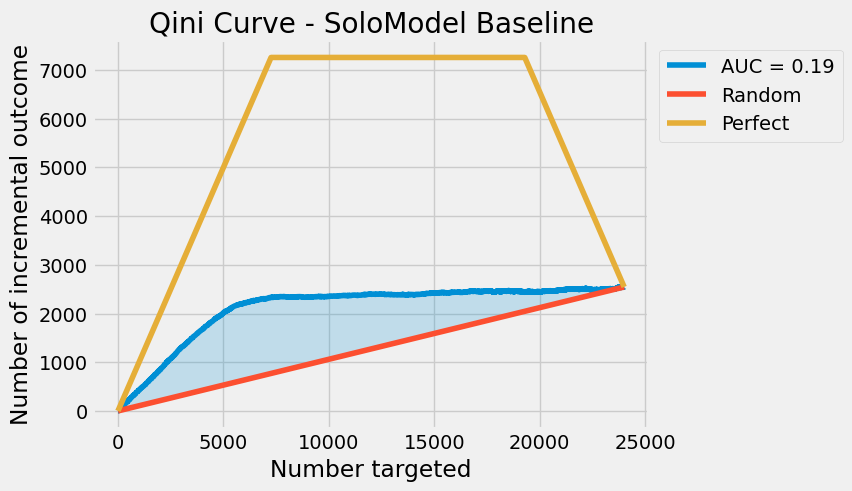

In [267]:
X = other_ads.drop(columns=['target', 't_flag'])
y = other_ads['target']
treatment = other_ads['t_flag']

X_train, X_test, y_train, y_test, treat_train, treat_test = train_test_split(
    X, y, treatment, test_size=0.2, random_state=RANDOM_STATE, stratify=treatment
)

solo_pipeline = Pipeline([
    ('scaler', MinMaxScaler()),
    ('clf', LogisticRegression(solver='liblinear', random_state=RANDOM_STATE))
])
solo_model = SoloModel(estimator=solo_pipeline)
solo_model.fit(X_train, y_train, treatment=treat_train)
uplift_pred_solo = solo_model.predict(X_test)
qini_solo = qini_auc_score(y_test, uplift_pred_solo, treat_test)
print("SoloModel baseline Qini AUC:", qini_solo)
plt.figure(figsize=(8,6))
plot_qini_curve(y_test, uplift_pred_solo, treat_test)
plt.title("Qini Curve - SoloModel Baseline")
plt.show()

TwoModels Qini AUC: 0.20889439843455554


<Figure size 800x600 with 0 Axes>

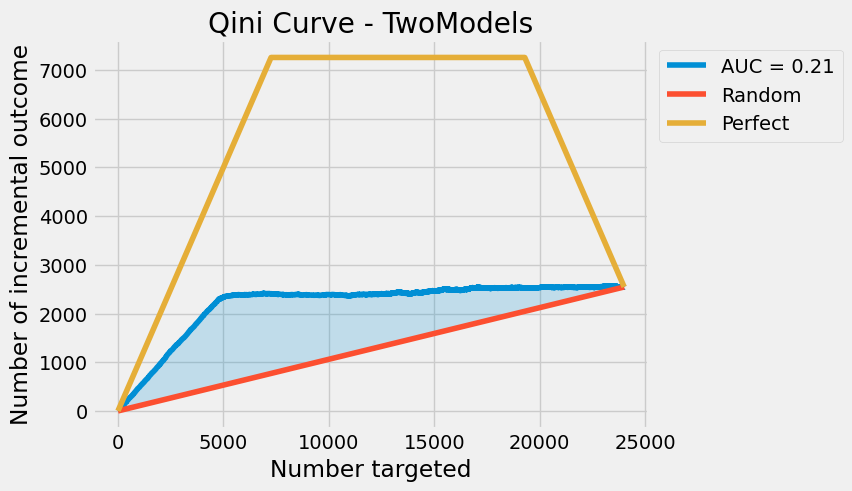

In [246]:
pipeline_control = Pipeline([
    ('scaler', MinMaxScaler()),
    ('clf', LogisticRegression(solver='liblinear', random_state=RANDOM_STATE))
])
pipeline_treatment = Pipeline([
    ('scaler', MinMaxScaler()),
    ('clf', LogisticRegression(solver='liblinear', random_state=RANDOM_STATE))
])
two_models = TwoModels(pipeline_treatment, pipeline_control)
two_models.fit(X_train, y_train, treatment=treat_train)
uplift_pred_two = two_models.predict(X_test)
qini_two = qini_auc_score(y_test, uplift_pred_two, treat_test)
print("TwoModels Qini AUC:", qini_two)
plt.figure(figsize=(8,6))
plot_qini_curve(y_test, uplift_pred_two, treat_test)
plt.title("Qini Curve - TwoModels")
plt.show()

ClassTransformation Qini AUC: 0.21015285070804146


<Figure size 800x600 with 0 Axes>

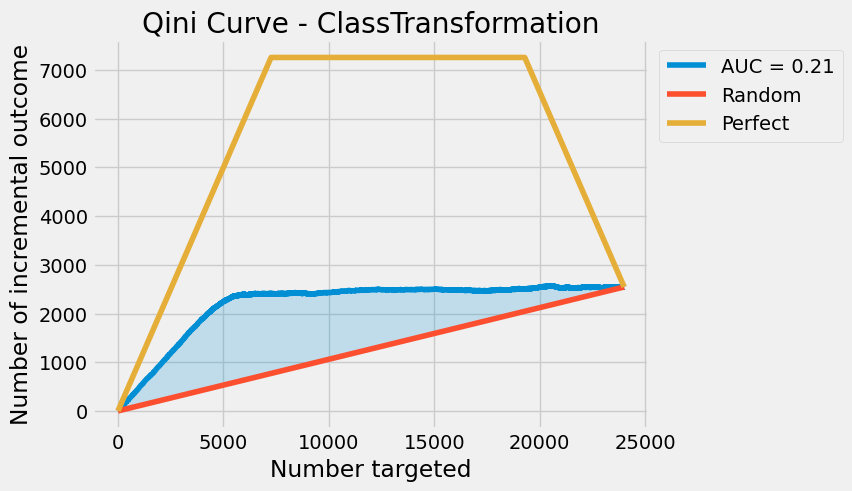

In [268]:
clf_calibrated = CalibratedClassifierCV(
    base_estimator=LogisticRegression(solver='liblinear', random_state=RANDOM_STATE),
    cv=3,
    method='sigmoid'
)
class_trans_pipeline = Pipeline([
    ('scaler', MinMaxScaler()),
    ('clf', clf_calibrated)
])

class_trans_model = ClassTransformation(estimator=class_trans_pipeline)
class_trans_model.fit(X_train, y_train, treatment=treat_train)
uplift_pred_class = class_trans_model.predict(X_test)
qini_class = qini_auc_score(y_test, uplift_pred_class, treat_test)
print("ClassTransformation Qini AUC:", qini_class)
plt.figure(figsize=(8,6))
plot_qini_curve(y_test, uplift_pred_class, treat_test)
plt.title("Qini Curve - ClassTransformation")
plt.show()

In [203]:
def objective(trial):
    C = trial.suggest_loguniform('C', 1e-4, 1e2)
    pipeline_tune = Pipeline([
        ('scaler', MinMaxScaler()),
        ('clf', CalibratedClassifierCV(
            base_estimator=LogisticRegression(C=C, solver='liblinear', random_state=RANDOM_STATE),
            cv=3,
            method='sigmoid'
        ))
    ])
    solo_model_tune = SoloModel(estimator=pipeline_tune)

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    scores = []
    for train_idx, val_idx in cv.split(X_train, treat_train):
        X_cv_train, X_cv_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_cv_train, y_cv_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        treat_cv_train, treat_cv_val = treat_train.iloc[train_idx], treat_train.iloc[val_idx]
        solo_model_tune.fit(X_cv_train, y_cv_train, treatment=treat_cv_train)
        uplift_pred_cv = solo_model_tune.predict(X_cv_val)
        score = qini_auc_score(y_cv_val, uplift_pred_cv, treat_cv_val)
        scores.append(score)
    return np.mean(scores)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20)

[I 2025-03-02 19:14:29,611] A new study created in memory with name: no-name-192b0607-29ea-4cd7-b458-bbc1b7f0f169
[I 2025-03-02 19:14:37,190] Trial 0 finished with value: 0.20334422352862247 and parameters: {'C': 12.000282540194164}. Best is trial 0 with value: 0.20334422352862247.
[I 2025-03-02 19:14:43,130] Trial 1 finished with value: 0.2034976181988748 and parameters: {'C': 64.27013077565239}. Best is trial 1 with value: 0.2034976181988748.
[I 2025-03-02 19:14:46,115] Trial 2 finished with value: 0.09495593999698755 and parameters: {'C': 0.0011144994179353984}. Best is trial 1 with value: 0.2034976181988748.
[I 2025-03-02 19:14:54,628] Trial 3 finished with value: 0.20273117019540904 and parameters: {'C': 3.031284542766617}. Best is trial 1 with value: 0.2034976181988748.
[I 2025-03-02 19:14:57,151] Trial 4 finished with value: 0.07412992461280876 and parameters: {'C': 0.00024663238897675125}. Best is trial 1 with value: 0.2034976181988748.
[I 2025-03-02 19:15:04,996] Trial 5 finis

In [204]:
print("Best hyperparameters from Optuna:", study.best_params)
print("Best CV Qini AUC (Optuna SoloModel):", study.best_value)

Best hyperparameters from Optuna: {'C': 98.73560983409847}
Best CV Qini AUC (Optuna SoloModel): 0.20351100365448907


UpliftRandomForest Qini AUC: 0.20684431157305502


<Figure size 800x600 with 0 Axes>

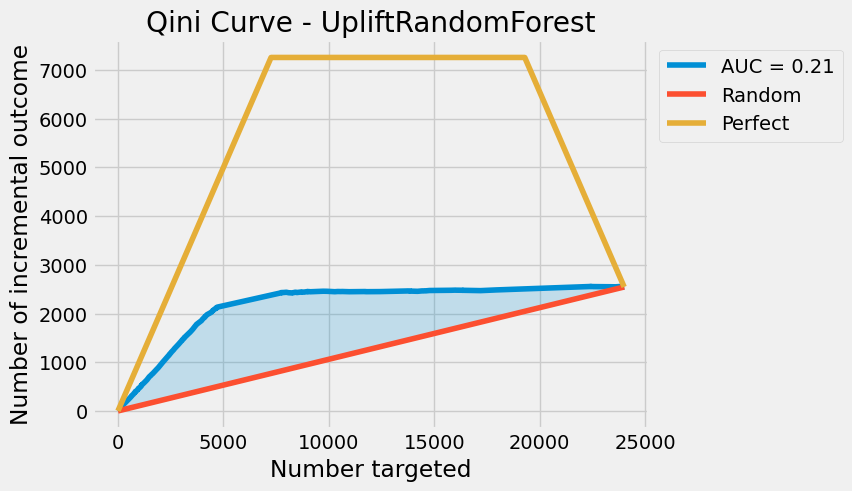

In [220]:
uplift_rf = UpliftRandomForestClassifier(
    control_name='0',
    random_state=RANDOM_STATE
)


uplift_rf.fit(X=X_train.values,
                  y=y_train.values,
                  treatment=treat_train.astype(str).values)
uplift_pred_rf = uplift_rf.predict(X=X_test.values)
qini_rf = qini_auc_score(y_true=y_test,
                 uplift=uplift_pred_rf.reshape(-1),
                 treatment=treat_test.astype('int'))

print("UpliftRandomForest Qini AUC:", qini_rf)
plt.figure(figsize=(8,6))
plot_qini_curve(y_true=y_test,
                  uplift=pd.Series(uplift_pred_rf.reshape(-1), index=X_test.index),
                  treatment=treat_test.astype(int))
plt.title("Qini Curve - UpliftRandomForest")
plt.show()

In [285]:
model_other = class_trans_model

<h2>4. Подготовка ответа в требуемом формате и подготовка выводов (6 баллов)</h2>

a) Сделайте скоринг нужных клиентов, подготовьте ответ в требуемом формате

б) Сделайте краткую аналитику того, какой канал взаимодействия наиболее предпочтителен

в) Сделайте выводы по проделанной работе

**Комментарий по заданиям и оцениванию:**

* Подготовлен только ответ - **1 балл**
* Подготовлен содержательный вывод по проделанной работе - **4 балла**
* Корректно принято решение об отправке/не отправке коммуникации клиентам в зависимости от значений Uplift - **1 балл**

In [286]:
january_data = features[features['report_dt'] == '2025-01-31'].copy()
print("Количество пользователей в январе:", january_data['user_id'].nunique())

Количество пользователей в январе: 460000


In [287]:
january_processed = pd.get_dummies(january_data, columns=['city'], drop_first=True, dtype='int')

scaler = StandardScaler()

january_processed['age'] = scaler.fit_transform(january_processed[['age']])

In [288]:
january_processed.head(5)

,x1,x2,x3,x4,x5,x6,x7,x8,x9,report_dt,user_id,age,report_month,city_Smolensk,city_Ufa
104548,0.654343,-1.439286,-0.011475,2.039457,0.843580,-0.977480,-0.768019,-1.044127,0.025673,2025-01-31,1066338,-0.868409,2025-01,0,1
404628,0.238281,-1.221378,0.338246,2.578613,-0.738267,-0.293309,-1.623151,-0.419945,-0.285695,2025-01-31,25872,1.266371,2025-01,0,0
129453,1.262071,-0.590011,-1.487096,-0.966672,2.740715,0.312791,-0.356535,-0.539563,1.401530,2025-01-31,4107442,-0.601561,2025-01,1,0
281997,-6.942073,0.107627,1.760962,4.424731,1.980637,0.238544,-1.329872,0.288694,-1.625620,2025-01-31,2047420,-0.067867,2025-01,0,0
326691,-2.200147,0.694959,-1.620087,4.003986,0.808261,0.214216,-0.330887,-1.386118,1.525752,2025-01-31,1120643,-1.402104,2025-01,0,1


In [289]:
X_jan= january_processed.drop(columns=['report_month'])

In [290]:
uplift_push = model_push.predict(X_jan.drop(columns=['user_id','report_dt']))
uplift_banner = model_banner.predict(X_jan.drop(columns=['user_id','report_dt']))
uplift_other = model_other.predict(X_jan.drop(columns=['user_id','report_dt','x5', 'city_Smolensk', 'city_Ufa' ]))

In [291]:
uplift_push = uplift_push.ravel()
uplift_banner = uplift_banner.ravel()
uplift_other = uplift_other.ravel()

df_uplift = pd.DataFrame({
    'user_id': january_data['user_id'].values,
    'push': uplift_push,
    'banner': uplift_banner,
    'other_ads': uplift_other
})

In [297]:
channels = ['push', 'banner', 'other_ads']

def best_channel(row):

    max_ch = None
    max_val = float('-inf')
    for ch in channels:
        val = row[ch]
        if val > max_val:
            max_val = val
            max_ch = ch

    if max_val <= 0:
        return 'no_comm', 0.0
    else:
        return max_ch, max_val

df_uplift['channel'], df_uplift['uplift'] = zip(
    *df_uplift.apply(best_channel, axis=1)
)

df_uplift

,user_id,push,banner,other_ads,channel,uplift
0,1066338,0.194926,0.454728,0.456331,other_ads,0.456331
1,25872,0.389859,0.306711,0.301175,push,0.389859
2,4107442,0.507970,0.393796,0.368450,push,0.507970
3,2047420,0.083412,0.154570,0.129803,banner,0.154570
4,1120643,-0.103198,0.317398,0.313074,banner,0.317398
...,...,...,...,...,...,...
459995,4034876,-0.039374,0.442497,0.441792,banner,0.442497
459996,114148,0.740463,0.036282,0.027532,push,0.740463
459997,143255,0.232559,0.402021,0.373613,banner,0.402021
459998,132172,0.580200,0.186324,0.176515,push,0.580200


In [303]:
df_uplift.describe()

,user_id,push,banner,other_ads,uplift
count,4.600000e+05,460000.000000,460000.000000,460000.000000,460000.000000
mean,1.765210e+06,0.397204,0.216195,0.209151,0.559095
std,1.564331e+06,0.317355,0.313522,0.316659,0.147446
min,1.000000e+00,-0.871916,-0.891088,-0.897155,0.000000
25%,1.150008e+05,0.187527,0.020585,0.009762,0.448735
50%,2.010000e+06,0.461780,0.283925,0.276867,0.557731
75%,4.004999e+06,0.655786,0.454416,0.450114,0.672255
max,4.119999e+06,0.951594,0.887166,0.886180,0.951594


In [298]:
final_df = pd.DataFrame({
    'user_id': df_uplift['user_id'],
    'report_dt': '2025-01-31',
    'channel': df_uplift['channel'],
    'uplift': df_uplift['uplift']
})

final_df

,user_id,report_dt,channel,uplift
0,1066338,2025-01-31,other_ads,0.456331
1,25872,2025-01-31,push,0.389859
2,4107442,2025-01-31,push,0.507970
3,2047420,2025-01-31,banner,0.154570
4,1120643,2025-01-31,banner,0.317398
...,...,...,...,...
459995,4034876,2025-01-31,banner,0.442497
459996,114148,2025-01-31,push,0.740463
459997,143255,2025-01-31,banner,0.402021
459998,132172,2025-01-31,push,0.580200


In [299]:
final_df.groupby('channel')['uplift'].mean()

,uplift
channel,
banner,0.479574
no_comm,0.000000
other_ads,0.502498
push,0.605702


In [302]:
final_df['channel'].value_counts()

,count
channel,
push,277726
banner,114613
other_ads,67660
no_comm,1


## Выводы о проделанной работе

### Сбор и подготовка данных
* Из исходных таблиц были собраны необходимые наборы данных.
* Учтён двухмесячный лаг при формировании обучающей выборки, чтобы избежать утечки данных (лида).
* Признаки были очищены и закодированы (One-Hot Encoding для категориальных переменных), а даты и категориальные поля переведены в числовой формат.
* Кампания sms была удалена, потому что присутствовали проблемы с обучающей выборкой

### Построение таргета и разделение на группы
* Сформирован таргет с учётом задачи: для целевой группы (t_flag=1) — покупка в течение 2 недель после коммуникации, для контрольной группы (t_flag=0) — покупка в течение 3 недель с начала кампании.
* Убедились, что контрольная и целевая группы корректно отражены в данных (t_flag=0/1).

### Обучение моделей uplift
* Реализованы различные подходы (SoloModel, TwoModels, ClassTransformation, UpliftRandomForest), с тюнингом гиперпараметров (Optuna).
* Проверена корректность расчёта uplift (разница вероятностей «купит при коммуникации» и «купит без коммуникации»).
* Оценено качество моделей через метрики (Qini AUC), построены Qini‑кривые.

### Прогноз на данных за январь 2025
* Подготовлены фичи за январь 2025 (учтены кодировки, формат и лаг в 2 месяца).
* Для каждого пользователя рассчитан uplift по нескольким каналам (push, banner, other_ads).
* Выбран канал с максимальным uplift, при отсутствии положительного эффекта — no_comm.

### Самый предпочтительный канал коммуникации как по частоте, так и по среднему uplift – push-уведомления.